# GNN-Enhanced Smart Contract Vulnerability Detection

## Setup (Cell 3 Alt)
1. Clones the curated dataset:
   `git clone https://github.com/smartbugs/smartbugs-curated`
2. Downloads `wild_pseudo_labels.json` and `wild_dataset.pkl` to Colab

## Skippable long-running cells
- **Cell 3** (pseudo-labeling, ~45 min): skip if `wild_pseudo_labels.json` is provided
- **Cell 3b** (graph building, ~3 hrs): skip if `wild_dataset.pkl` is provided
  — Cell 3c loads it automatically from the pkl

## No manual file uploads needed for
- Test `.sol` contracts — created automatically by the sol-creator cell
- Hard-negative `.sol` contracts — created automatically before Cell 7
- `.pt` model files — saved to `/content/` during training (Cells 19 and 9)

## Dataset
- Train: SmartBugs Wild — 8111 graphs (pseudo-labeled)
- Test: SmartBugs Curated — 121 graphs

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install torch torch_geometric -q
!pip install slither-analyzer -q
!pip install py-solc-x -q
!pip install matplotlib seaborn scikit-learn -q

import solcx
solcx.install_solc('0.4.22')
print('Setup complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.1/752.1 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.4/468.

In [2]:
# ── Cell 2: Helper functions ──────────────────────────────────────────────
import json, os, re, torch
from slither import Slither
from slither.core.declarations import FunctionContract
from solcx import install_solc
from torch_geometric.data import Data

# ── helpers ───────────────────────────────────────────────────────────────────
def sends_ether(func):
    try:
        for node in func.nodes:
            for ir in node.irs:
                if hasattr(ir, 'call_value') and ir.call_value:
                    return True
        return False
    except:
        return False

def calls_selfdestruct(func):
    """Returns 1 if any node in the function calls selfdestruct/suicide."""
    try:
        for node in func.nodes:
            for ir in node.irs:
                ir_str = str(ir).lower()
                if 'selfdestruct' in ir_str or 'suicide' in ir_str:
                    return 1
        return 0
    except:
        return 0

def cyclomatic_complexity(func):
    """Approximates complexity as number of branch/loop nodes in the CFG."""
    try:
        from slither.core.cfg.node import NodeType
        branch_types = {
            NodeType.IF, NodeType.IFLOOP,
            NodeType.STARTLOOP, NodeType.ENDLOOP
        }
        return sum(1 for n in func.nodes if n.type in branch_types)
    except:
        return 0

def has_modifier_usage(func):
    """Returns 1 if the function uses any modifier (access-control signal)."""
    try:
        return 1 if func.modifiers else 0
    except:
        return 0

# ── main extraction function ──────────────────────────────────────────────────
from solcx.install import get_executable

def extract_graph(sol_file, solc_version=None, vulnerable_lines=None):
    try:
        if solc_version:
            clean_version = re.search(r'\d+\.\d+\.\d+', str(solc_version))
            clean_version = clean_version.group() if clean_version else '0.4.25'
        else:
            clean_version = '0.4.25'

        major, minor, patch = map(int, clean_version.split('.'))
        if major == 0 and minor == 4 and patch < 11:
            return [], [], [], [], {}

        install_solc(clean_version, show_progress=False)

        try:
            binary_path = str(get_executable(clean_version))
        except Exception:
            return [], [], [], [], {}

        if not os.path.exists(binary_path):
            return [], [], [], [], {}

        slither = Slither(sol_file, solc=binary_path)

        nodes         = []
        call_edges    = []
        state_edges   = []
        labels        = []
        node_id       = {}
        func_line_map = {}

        for contract in slither.contracts:
            for func in contract.functions:
                if not isinstance(func, FunctionContract):
                    continue

                fid = len(nodes)
                node_id[func.canonical_name] = fid

                func_lines = set()
                for node in func.nodes:
                    if node.source_mapping and node.source_mapping.lines:
                        func_lines.update(node.source_mapping.lines)
                func_line_map[func.canonical_name] = func_lines

                is_vuln = 0
                if vulnerable_lines and func_lines:
                    if vulnerable_lines & func_lines:
                        is_vuln = 1

                nodes.append({
                    'id': fid, 'name': func.canonical_name,
                    'loc':                len(func.nodes),
                    'params':             len(func.parameters),
                    'external_calls':     len(func.external_calls_as_expressions),
                    'sends_eth':          int(sends_ether(func)),
                    'visibility':         1 if getattr(func, 'visibility', '') == 'public' else 0,
                    'is_modifier':        0,
                    'state_vars_read':    len(getattr(func, 'state_variables_read', [])),
                    'state_vars_written': len(getattr(func, 'state_variables_written', [])),
                    'is_payable':         1 if getattr(func, 'payable', False) else 0,
                    'cyclo':              cyclomatic_complexity(func),
                    'self_destruct':      calls_selfdestruct(func),
                    'has_modifier':       has_modifier_usage(func),
                })
                labels.append(is_vuln)

        for contract in slither.contracts:
            for func in contract.functions:
                if not isinstance(func, FunctionContract):
                    continue
                src = node_id.get(func.canonical_name)
                if src is None:
                    continue
                for node in func.nodes:
                    for ir in node.irs:
                        if hasattr(ir, 'function') and isinstance(ir.function, FunctionContract):
                            tgt = node_id.get(ir.function.canonical_name)
                            if tgt is not None and src != tgt:
                                call_edges.append([src, tgt])

        for contract in slither.contracts:
            for var in contract.state_variables:
                writers = [f for f in contract.functions
                           if isinstance(f, FunctionContract)
                           and var in getattr(f, 'state_variables_written', [])]
                readers = [f for f in contract.functions
                           if isinstance(f, FunctionContract)
                           and var in getattr(f, 'state_variables_read', [])]
                for w in writers:
                    for r in readers:
                        if w.canonical_name != r.canonical_name:
                            src = node_id.get(w.canonical_name)
                            tgt = node_id.get(r.canonical_name)
                            if src is not None and tgt is not None:
                                state_edges.append([src, tgt])

        call_edges  = [list(e) for e in set(tuple(e) for e in call_edges)]
        state_edges = [list(e) for e in set(tuple(e) for e in state_edges)]
        return nodes, call_edges, state_edges, labels, func_line_map

    except Exception:
        return [], [], [], [], {}

print('extract_graph redefined with fixed Windows path.')


def build_pyg_graph(nodes, call_edges, state_edges, labels, func_line_map):
    """
    Builds a PyG Data object with:
      x            : (N, 12) float tensor of hybrid features
      edge_index   : (2, E)  all edges combined
      edge_type    : (E,)    0=call, 1=state-flow
      y            : (N,)    vulnerability labels
      func_names   : list of canonical function names (for explainer)
      func_lines   : dict name→set of lines (for heatmap)
    """
    x = torch.tensor([
        [
            n['loc'], n['params'], n['external_calls'], n['sends_eth'],
            n['visibility'], n['is_modifier'], n['state_vars_read'],
            n['state_vars_written'],
            n['is_payable'], n['cyclo'], n['self_destruct'], n['has_modifier']
        ]
        for n in nodes
    ], dtype=torch.float)

    all_edges = call_edges + state_edges
    edge_type = ([0] * len(call_edges)) + ([1] * len(state_edges))

    if all_edges:
        edge_index = torch.tensor(all_edges, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_type, dtype=torch.long)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros(0, dtype=torch.long)

    y = torch.tensor(labels, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.func_names = [n['name'] for n in nodes]
    data.func_lines = func_line_map
    return data

print('Feature extraction functions defined (12 features + state-flow edges).')

extract_graph redefined with fixed Windows path.
Feature extraction functions defined (12 features + state-flow edges).


In [3]:
# Cell 3 Alt
# Skip if running Cells 3 and 3b from scratch
!git clone https://github.com/smartbugs/smartbugs-curated
import gdown
gdown.download('https://drive.google.com/uc?id=1nhHARY658fDooNJKQZAgFjx5u7Xn8mpb', 'wild_pseudo_labels.json')
gdown.download('https://drive.google.com/uc?id=1KL7VDdARAh0DEz_dYau1jWwc5L-rzORe', 'wild_dataset.pkl')

Cloning into 'smartbugs-curated'...
remote: Enumerating objects: 225, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 225 (delta 29), reused 19 (delta 19), pack-reused 177 (from 1)
Receiving objects: 100% (225/225), 173.89 KiB | 856.00 KiB/s, done.
Resolving deltas: 100% (65/65), done.


Downloading...
From: https://drive.google.com/uc?id=1nhHARY658fDooNJKQZAgFjx5u7Xn8mpb
To: /content/wild_pseudo_labels.json
100%|██████████| 3.58M/3.58M [00:00<00:00, 55.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KL7VDdARAh0DEz_dYau1jWwc5L-rzORe
To: /content/wild_dataset.pkl
100%|██████████| 72.4M/72.4M [00:00<00:00, 77.6MB/s]


'wild_dataset.pkl'

In [ ]:
# ── Cell 3: Pseudo-labeling ──────────────────────────────────────────────
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

def process_one(sol_file):
    import subprocess, json, re, os
    from collections import defaultdict
    from solcx import install_solc
    from solcx.install import get_executable

    DETECTOR_TO_CATEGORY = {
        'reentrancy-eth':          'reentrancy',
        'reentrancy-no-eth':       'reentrancy',
        'reentrancy-benign':       'reentrancy',
        'unchecked-lowlevel':      'unchecked_low_level_calls',
        'unchecked-send':          'unchecked_low_level_calls',
        'timestamp':               'time_manipulation',
        'weak-prng':               'bad_randomness',
        'tx-origin':               'access_control',
        'suicidal':                'access_control',
        'controlled-delegatecall': 'access_control',
        'calls-loop':              'denial_of_service',
    }
    DETECTORS_TO_RUN = ','.join(DETECTOR_TO_CATEGORY.keys())

    def detect_solc_version(path):
        try:
            with open(path, 'r', errors='ignore') as f:
                content = f.read(2000)
            m = re.search(r'pragma\s+solidity\s+[^;]*?(\d+\.\d+\.\d+)', content)
            if m:
                return m.group(1)
        except:
            pass
        return '0.4.25'

    try:
        version = detect_solc_version(sol_file)
        major, minor, patch = map(int, version.split('.'))
        if major == 0 and minor == 4 and patch < 11:
            return sol_file, None

        install_solc(version, show_progress=False)
        binary = str(get_executable(version))
        if not os.path.exists(binary):
            return sol_file, None

        result = subprocess.run(
            ['slither', sol_file, '--solc', binary,
             '--json', '-', '--detect', DETECTORS_TO_RUN],
            capture_output=True, text=True, timeout=30
        )
        raw = result.stdout.strip()
        if not raw:
            return sol_file, {}

        json_start = raw.find('{')
        if json_start == -1:
            return sol_file, {}
        data = json.loads(raw[json_start:])

        vuln_lines = defaultdict(set)
        for dr in data.get('results', {}).get('detectors', []):
            check    = dr.get('check', '')
            category = DETECTOR_TO_CATEGORY.get(check)
            if category is None:
                continue
            for element in dr.get('elements', []):
                src = element.get('source_mapping', {})
                for line in src.get('lines', []):
                    vuln_lines[category].add(int(line))

        return sol_file, {k: list(v) for k, v in vuln_lines.items()}

    except Exception:
        return sol_file, None


# ── Parallel labeling loop ─────────────────────────────────────────────────────
from joblib import Parallel, delayed
import glob, json, os
from tqdm import tqdm

CACHE_FILE    = 'wild_pseudo_labels.json'
MAX_CONTRACTS = 15000

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        cache = json.load(f)
    print(f'Loaded {len(cache)} cached entries.')
else:
    cache = {}

all_sol_files = glob.glob('smartbugs-wild/**/*.sol', recursive=True)[:MAX_CONTRACTS]
todo = [f for f in all_sol_files if f not in cache]
print(f'Remaining: {len(todo)} contracts')

N_WORKERS = 20
print(f'Workers: {N_WORKERS}')

# Process in chunks so we can checkpoint periodically
CHUNK_SIZE = 500
chunks = [todo[i:i+CHUNK_SIZE] for i in range(0, len(todo), CHUNK_SIZE)]

for chunk_idx, chunk in enumerate(chunks):
    results = Parallel(n_jobs=N_WORKERS, backend='loky')(
        delayed(process_one)(f) for f in tqdm(chunk, desc=f'Chunk {chunk_idx+1}/{len(chunks)}')
    )
    for sol_file, result in results:
        cache[sol_file] = result

    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f)
    print(f'Checkpoint saved — {len(cache)} total entries')

print(f'\nDone. Total cached: {len(cache)}')

Loaded 15000 cached entries.
Remaining: 0 contracts
Workers: 20

Done. Total cached: 15000


In [ ]:
# ── Cache stats inspection ───────────────────────────────────────

with open('wild_pseudo_labels.json') as f:
    cache = json.load(f)

none_count  = sum(1 for v in cache.values() if v is None)
empty_count = sum(1 for v in cache.values() if v == {})
vuln_count  = sum(1 for v in cache.values() if v)

print(f'Failed/timeout : {none_count}')
print(f'Clean (no vuln): {empty_count}')
print(f'Has vulns      : {vuln_count}')
print(f'Vuln rate      : {vuln_count / max(len(cache), 1):.1%}')

Failed/timeout : 1471
Clean (no vuln): 9286
Has vulns      : 4243
Vuln rate      : 28.3%


In [ ]:
# ── Cell 3b: Graph building ───────────────────────────────────────────────────────────────────

import json, os, re, torch, pickle, threading
from solcx import install_solc
from solcx.install import get_executable
from slither import Slither
from slither.core.declarations import FunctionContract
from tqdm import tqdm
from collections import Counter

CACHE_FILE    = 'wild_pseudo_labels.json'
PROGRESS_FILE = 'wild_progress.json'
DATASET_FILE  = 'wild_dataset.pkl'
CATEGORIES    = [
    'reentrancy', 'unchecked_low_level_calls', 'time_manipulation',
    'bad_randomness', 'access_control', 'denial_of_service'
]

def detect_solc_version(path):
    try:
        with open(path, 'r', errors='ignore') as f:
            content = f.read(2000)
        m = re.search(r'pragma\s+solidity\s+[^;]*?(\d+\.\d+\.\d+)', content)
        if m:
            return m.group(1)
    except:
        pass
    return '0.4.25'

def extract_graph(sol_file, solc_version=None, vulnerable_lines=None):
    try:
        if solc_version:
            clean_version = re.search(r'\d+\.\d+\.\d+', str(solc_version))
            clean_version = clean_version.group() if clean_version else '0.4.25'
        else:
            clean_version = '0.4.25'

        major, minor, patch = map(int, clean_version.split('.'))
        if major == 0 and minor == 4 and patch < 11:
            return [], [], [], [], {}

        install_solc(clean_version, show_progress=False)

        try:
            binary_path = str(get_executable(clean_version))
        except Exception:
            return [], [], [], [], {}

        if not os.path.exists(binary_path):
            return [], [], [], [], {}

        slither = Slither(sol_file, solc=binary_path)

        nodes         = []
        call_edges    = []
        state_edges   = []
        labels        = []
        node_id       = {}
        func_line_map = {}

        for contract in slither.contracts:
            for func in contract.functions:
                if not isinstance(func, FunctionContract):
                    continue

                fid = len(nodes)
                node_id[func.canonical_name] = fid

                func_lines = set()
                for node in func.nodes:
                    if node.source_mapping and node.source_mapping.lines:
                        func_lines.update(node.source_mapping.lines)
                func_line_map[func.canonical_name] = func_lines

                is_vuln = 0
                if vulnerable_lines and func_lines:
                    if vulnerable_lines & func_lines:
                        is_vuln = 1

                nodes.append({
                    'id': fid, 'name': func.canonical_name,
                    'loc':               len(func.nodes),
                    'params':            len(func.parameters),
                    'external_calls':    len(func.external_calls_as_expressions),
                    'sends_eth':         int(sends_ether(func)),
                    'visibility':        1 if getattr(func, 'visibility', '') == 'public' else 0,
                    'is_modifier':       0,
                    'state_vars_read':   len(getattr(func, 'state_variables_read', [])),
                    'state_vars_written':len(getattr(func, 'state_variables_written', [])),
                    'is_payable':        1 if getattr(func, 'payable', False) else 0,
                    'cyclo':             cyclomatic_complexity(func),
                    'self_destruct':     calls_selfdestruct(func),
                    'has_modifier':      has_modifier_usage(func),
                })
                labels.append(is_vuln)

        for contract in slither.contracts:
            for func in contract.functions:
                if not isinstance(func, FunctionContract):
                    continue
                src = node_id.get(func.canonical_name)
                if src is None:
                    continue
                for node in func.nodes:
                    for ir in node.irs:
                        if hasattr(ir, 'function') and isinstance(ir.function, FunctionContract):
                            tgt = node_id.get(ir.function.canonical_name)
                            if tgt is not None and src != tgt:
                                call_edges.append([src, tgt])

        for contract in slither.contracts:
            for var in contract.state_variables:
                writers = [f for f in contract.functions
                           if isinstance(f, FunctionContract)
                           and var in getattr(f, 'state_variables_written', [])]
                readers = [f for f in contract.functions
                           if isinstance(f, FunctionContract)
                           and var in getattr(f, 'state_variables_read', [])]
                for w in writers:
                    for r in readers:
                        if w.canonical_name != r.canonical_name:
                            src = node_id.get(w.canonical_name)
                            tgt = node_id.get(r.canonical_name)
                            if src is not None and tgt is not None:
                                state_edges.append([src, tgt])

        call_edges  = [list(e) for e in set(tuple(e) for e in call_edges)]
        state_edges = [list(e) for e in set(tuple(e) for e in state_edges)]
        return nodes, call_edges, state_edges, labels, func_line_map

    except Exception:
        return [], [], [], [], {}


def extract_graph_with_timeout(sol_file, solc_version=None, vulnerable_lines=None, timeout=45):
    result = [[], [], [], [], {}]
    def target():
        try:
            result[0], result[1], result[2], result[3], result[4] = extract_graph(
                sol_file, solc_version=solc_version, vulnerable_lines=vulnerable_lines)
        except Exception:
            pass
    t = threading.Thread(target=target)
    t.daemon = True
    t.start()
    t.join(timeout=timeout)
    return result[0], result[1], result[2], result[3], result[4]


# ── Load cache ─────────────────────────────────────────────────────────────────
with open(CACHE_FILE) as f:
    cache = json.load(f)

# ── Resume if checkpoint exists ────────────────────────────────────────────────
if os.path.exists(PROGRESS_FILE) and os.path.exists(DATASET_FILE):
    with open(PROGRESS_FILE) as f:
        progress = json.load(f)
    with open(DATASET_FILE, 'rb') as f:
        dataset_wild = pickle.load(f)
    already_done     = set(progress['done_files'])
    skipped_wild     = progress['skipped']
    call_edge_count  = progress['call_edges']
    state_edge_count = progress['state_edges']
    print(f'Resuming — {len(already_done)} done, {len(dataset_wild)} graphs loaded')
else:
    dataset_wild     = []
    already_done     = set()
    skipped_wild     = 0
    call_edge_count  = 0
    state_edge_count = 0
    print('Starting fresh')

# ── Main loop ──────────────────────────────────────────────────────────────────
for sol_file, label_data in tqdm(cache.items()):
    if sol_file in already_done:
        continue

    if label_data is None or not os.path.exists(sol_file):
        skipped_wild += 1
        already_done.add(sol_file)
        continue

    all_vuln_lines = set()
    present_types  = []
    for cat, lines in label_data.items():
        all_vuln_lines.update(lines)
        if lines:
            present_types.append(cat)

    version = detect_solc_version(sol_file)
    nodes, call_edges, state_edges, labels, func_line_map = extract_graph_with_timeout(
        sol_file, solc_version=version, vulnerable_lines=all_vuln_lines, timeout=45
    )

    already_done.add(sol_file)

    if not nodes:
        skipped_wild += 1
    else:
        graph = build_pyg_graph(nodes, call_edges, state_edges, labels, func_line_map)
        graph.vuln_types = present_types
        graph.source     = sol_file
        dataset_wild.append(graph)
        call_edge_count  += len(call_edges)
        state_edge_count += len(state_edges)

    if len(already_done) % 100 == 0:
        import gc
        gc.collect()
        with open(PROGRESS_FILE, 'w') as f:
            json.dump({'done_files': list(already_done), 'skipped': skipped_wild,
                       'call_edges': call_edge_count, 'state_edges': state_edge_count}, f)
        with open(DATASET_FILE, 'wb') as f:
            pickle.dump(dataset_wild, f)
        print(f'Checkpoint: {len(already_done)} done, {len(dataset_wild)} graphs')

# ── Final save ─────────────────────────────────────────────────────────────────
with open(PROGRESS_FILE, 'w') as f:
    json.dump({'done_files': list(already_done), 'skipped': skipped_wild,
               'call_edges': call_edge_count, 'state_edges': state_edge_count}, f)
with open(DATASET_FILE, 'wb') as f:
    pickle.dump(dataset_wild, f)

# ── Summary ────────────────────────────────────────────────────────────────────
vuln_nodes = sum(g.y.sum().item() for g in dataset_wild)
safe_nodes = sum((g.y == 0).sum().item() for g in dataset_wild)
print(f'Wild graphs built  : {len(dataset_wild)}')
print(f'Skipped            : {skipped_wild}')
print(f'Call edges total   : {call_edge_count}')
print(f'State-flow edges   : {state_edge_count}')
print(f'Vulnerable nodes   : {int(vuln_nodes)}')
print(f'Safe nodes         : {int(safe_nodes)}')
print(f'Imbalance ratio    : {safe_nodes/max(int(vuln_nodes),1):.1f}x')

print('\nContracts per vulnerability type:')
type_counter = Counter()
for g in dataset_wild:
    for t in g.vuln_types:
        type_counter[t] += 1
for cat in CATEGORIES:
    print(f'  {cat:<35}: {type_counter.get(cat, 0)}')

Resuming — 12900 done, 6558 graphs loaded


 86%|████████████████████████▉    | 12901/15000 [00:00<00:00, 34267.57it/s]ERROR:SlitherSolcParsing:
Failed to generate IR for KingOfNarnia.bid. Please open an issue https://github.com/crytic/slither/issues.
KingOfNarnia.bid (smartbugs-wild/contracts/0x46d7f2fc523728670e1eb7184a7c8a4a0f0a4cfa.sol#106-148):
 	require(bool)(! isContract(msg.sender))
	require(bool)(bytes(_message).length <= maxMessageChars)
	require(bool)(msg.value > 0)
	_roundNumber == currentRoundNumber && ! roundExpired()
	require(bool)(msg.value > lastBidAmount)
	_roundNumber == (currentRoundNumber + 1) && roundExpired()
	lastRoundPotBalance = this.balance.sub(msg.value)
	devFee = lastRoundPotBalance.mul(devFeePercent).div(100)
	owner.transfer(devFee)
	winnings = lastRoundPotBalance.sub(devFee).mul(100 - rolloverPercent).div(100)
	king.transfer(winnings)
	roundToKing[currentRoundNumber] = king
	roundToWinnings[currentRoundNumber] = winnings
	roundToFinalBid[currentRoundNumber] = lastBidAmount
	roundToFinalMessage[curr

Checkpoint: 13200 done, 6788 graphs


 89%|████████████████████████████▎   | 13299/15000 [03:17<09:36,  2.95it/s]

Checkpoint: 13300 done, 6859 graphs


...

Checkpoint: 14900 done, 8036 graphs


100%|███████████████████████████████▊| 14940/15000 [18:28<00:31,  1.88it/s]ERROR:SlitherSolcParsing:
Failed to generate IR for ChronosFinance.withdrawFreeBalance. Please open an issue https://github.com/crytic/slither/issues.
ChronosFinance.withdrawFreeBalance (smartbugs-wild/contracts/0x51d32fb6c763878f44f93907d7f88fd9ef370595.sol#409-414):
 	freeBalance = this.balance.sub(totalPayments).sub(prizePool).sub(wagerPool)
	cfoAddress.transfer(freeBalance)
	onlyCFO()
100%|███████████████████████████████▉| 14999/15000 [19:03<00:00,  2.57it/s]

Checkpoint: 15000 done, 8111 graphs


100%|████████████████████████████████| 15000/15000 [19:08<00:00, 13.07it/s]


Wild graphs built  : 8111
Skipped            : 6889
Call edges total   : 148938
State-flow edges   : 345684
Vulnerable nodes   : 29602
Safe nodes         : 433703
Imbalance ratio    : 14.7x

Contracts per vulnerability type:
  reentrancy                         : 1581
  unchecked_low_level_calls          : 151
  time_manipulation                  : 2067
  bad_randomness                     : 211
  access_control                     : 65
  denial_of_service                  : 780


In [4]:
# ── Cell 3c: Loading dataset ───────────────────────────────────────────────────────────────────
import torch, pickle
if 'dataset_wild' in globals() and len(dataset_wild) > 0:
    torch.save(dataset_wild, 'wild_dataset_torch.pt')
    print(f'Saved {len(dataset_wild)} graphs to wild_dataset_torch.pt')

with open('wild_dataset.pkl', 'rb') as f:
    dataset_wild = pickle.load(f)
print(f'Loaded {len(dataset_wild)} Wild graphs')

Loaded 8111 Wild graphs


In [5]:
# ── Cell 3d: process_one() definition only (skip the 45-min Wild labeling loop) ──
def process_one(sol_file):
    import subprocess, json, re, os
    from collections import defaultdict
    from solcx import install_solc
    from solcx.install import get_executable

    DETECTOR_TO_CATEGORY = {
        'reentrancy-eth':          'reentrancy',
        'reentrancy-no-eth':       'reentrancy',
        'reentrancy-benign':       'reentrancy',
        'unchecked-lowlevel':      'unchecked_low_level_calls',
        'unchecked-send':          'unchecked_low_level_calls',
        'timestamp':               'time_manipulation',
        'weak-prng':               'bad_randomness',
        'tx-origin':               'access_control',
        'suicidal':                'access_control',
        'controlled-delegatecall': 'access_control',
        'calls-loop':              'denial_of_service',
    }
    DETECTORS_TO_RUN = ','.join(DETECTOR_TO_CATEGORY.keys())

    def detect_solc_version(path):
        try:
            with open(path, 'r', errors='ignore') as f:
                content = f.read(2000)
            m = re.search(r'pragma\s+solidity\s+[^;]*?(\d+\.\d+\.\d+)', content)
            if m:
                return m.group(1)
        except:
            pass
        return '0.4.25'

    try:
        version = detect_solc_version(sol_file)
        major, minor, patch = map(int, version.split('.'))
        if major == 0 and minor == 4 and patch < 11:
            return sol_file, None

        install_solc(version, show_progress=False)
        binary = str(get_executable(version))
        if not os.path.exists(binary):
            return sol_file, None

        result = subprocess.run(
            ['slither', sol_file, '--solc', binary,
             '--json', '-', '--detect', DETECTORS_TO_RUN],
            capture_output=True, text=True, timeout=30
        )
        raw = result.stdout.strip()
        if not raw:
            return sol_file, {}

        json_start = raw.find('{')
        if json_start == -1:
            return sol_file, {}
        data = json.loads(raw[json_start:])

        vuln_lines = defaultdict(set)
        for dr in data.get('results', {}).get('detectors', []):
            check    = dr.get('check', '')
            category = DETECTOR_TO_CATEGORY.get(check)
            if category is None:
                continue
            for element in dr.get('elements', []):
                src = element.get('source_mapping', {})
                for line in src.get('lines', []):
                    vuln_lines[category].add(int(line))

        return sol_file, {k: list(v) for k, v in vuln_lines.items()}

    except Exception:
        return sol_file, None

print('process_one() defined (Slither detector logic only, no Wild loop).')

process_one() defined (Slither detector logic only, no Wild loop).


In [6]:
# ── Cell 4:  ───────────────────────────────────────────────────────────────────
dataset      = []
skipped      = 0
call_edge_count  = 0
state_edge_count = 0

with open('smartbugs-curated/vulnerabilities.json') as f:
    all_items = json.load(f)

for item in all_items:
    full_path    = os.path.join('smartbugs-curated', item['path'])
    solc_version = item.get('pragma')

    vulnerable_lines = set()
    if item.get('vulnerabilities'):
        for vuln in item['vulnerabilities']:
            for line in vuln.get('lines', []):
                vulnerable_lines.add(int(line))

    nodes, call_edges, state_edges, labels, func_line_map = extract_graph(
        full_path, solc_version=solc_version, vulnerable_lines=vulnerable_lines
    )

    if nodes:
        graph = build_pyg_graph(nodes, call_edges, state_edges, labels, func_line_map)
        dataset.append(graph)
        call_edge_count  += len(call_edges)
        state_edge_count += len(state_edges)
    else:
        skipped += 1

vuln = sum(1 for g in dataset for label in g.y.tolist() if label == 1)
safe = sum(1 for g in dataset for label in g.y.tolist() if label == 0)

print(f'Graphs built       : {len(dataset)}')
print(f'Skipped            : {skipped}')
print(f'Features per node  : {dataset[0].x.shape[1]}  (was 8, now 12)')
print(f'Call edges total   : {call_edge_count}')
print(f'State-flow edges   : {state_edge_count}  (NEW)')
print(f'Vulnerable nodes   : {vuln}')
print(f'Safe nodes         : {safe}')
print(f'Imbalance ratio    : {safe/max(vuln,1):.1f}x')

ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_bonus.withdrawReward. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_bonus.withdrawReward (smartbugs-curated/dataset/reentrancy/reentrancy_bonus.sol#16-21):
 	amountToWithdraw = rewardsForA[recipient]
	rewardsForA[recipient] = 0
	(success,None) = recipient.call.value(amountToWithdraw)()
	require(bool)(success)
ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_cross_function.withdrawBalance. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_cross_function.withdrawBalance (smartbugs-curated/dataset/reentrancy/reentrancy_cross_function.sol#21-27):
 	amountToWithdraw = userBalances[msg.sender]
	(success,None) = msg.sender.call.value(amountToWithdraw)()
	require(bool)(success)
	userBalances[msg.sender] = 0


Graphs built       : 121
Skipped            : 22
Features per node  : 12  (was 8, now 12)
Call edges total   : 301
State-flow edges   : 1198  (NEW)
Vulnerable nodes   : 161
Safe nodes         : 1231
Imbalance ratio    : 7.6x


In [7]:
# ── Cell 4b: Slither Baseline on Curated (predictions, not labels) ──
from sklearn.metrics import f1_score, precision_score, recall_score

slither_all_true, slither_all_pred, slither_skipped = [], [], 0

with open('smartbugs-curated/vulnerabilities.json') as f:
    all_items = json.load(f)

for item in all_items:
    full_path    = os.path.join('smartbugs-curated', item['path'])
    solc_version = item.get('pragma')

    # ground truth — identical to Cell 4
    vulnerable_lines = set()
    if item.get('vulnerabilities'):
        for vuln in item['vulnerabilities']:
            for line in vuln.get('lines', []):
                vulnerable_lines.add(int(line))

    nodes, _, _, labels, func_line_map = extract_graph(
        full_path, solc_version=solc_version, vulnerable_lines=vulnerable_lines
    )
    if not nodes:
        slither_skipped += 1
        continue

    # Slither's own detector hits, repurposed as the prediction
    _, pred_by_cat = process_one(full_path)
    pred_lines = set()
    if pred_by_cat:
        for lines in pred_by_cat.values():
            pred_lines.update(int(l) for l in lines)

    for func_name, gt_label in zip([n['name'] for n in nodes], labels):
        func_lines = func_line_map.get(func_name, set())
        pred_label = 1 if (pred_lines & func_lines) else 0
        slither_all_true.append(gt_label)
        slither_all_pred.append(pred_label)

f1  = f1_score(slither_all_true, slither_all_pred, zero_division=0)
pre = precision_score(slither_all_true, slither_all_pred, zero_division=0)
rec = recall_score(slither_all_true, slither_all_pred, zero_division=0)

print(f'Slither baseline on Curated ({len(all_items)-slither_skipped}/{len(all_items)} contracts parsed)')
print(f'  F1={f1:.3f}  Precision={pre:.3f}  Recall={rec:.3f}  (n={len(slither_all_true)} functions)')

ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_bonus.withdrawReward. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_bonus.withdrawReward (smartbugs-curated/dataset/reentrancy/reentrancy_bonus.sol#16-21):
 	amountToWithdraw = rewardsForA[recipient]
	rewardsForA[recipient] = 0
	(success,None) = recipient.call.value(amountToWithdraw)()
	require(bool)(success)
ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_cross_function.withdrawBalance. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_cross_function.withdrawBalance (smartbugs-curated/dataset/reentrancy/reentrancy_cross_function.sol#21-27):
 	amountToWithdraw = userBalances[msg.sender]
	(success,None) = msg.sender.call.value(amountToWithdraw)()
	require(bool)(success)
	userBalances[msg.sender] = 0


Slither baseline on Curated (121/143 contracts parsed)
  F1=0.500  Precision=0.401  Recall=0.665  (n=1392 functions)


In [8]:
# ── Cell 4c: Rebuild per-node category ground truth, positionally aligned with `dataset` ──
CATEGORIES = [
    'reentrancy', 'unchecked_low_level_calls', 'time_manipulation',
    'bad_randomness', 'access_control', 'denial_of_service'
]

dataset_categories = []  # one entry per graph in `dataset`, same order — each entry is a
                          # list of sets (one set of categories per node, aligned with graph.y)

with open('smartbugs-curated/vulnerabilities.json') as f:
    all_items = json.load(f)

for item in all_items:
    full_path    = os.path.join('smartbugs-curated', item['path'])
    solc_version = item.get('pragma')

    vulnerable_lines = set()
    cat_lines = {}
    if item.get('vulnerabilities'):
        for vuln in item['vulnerabilities']:
            for line in vuln.get('lines', []):
                vulnerable_lines.add(int(line))
            cat = vuln.get('category')
            if cat in CATEGORIES:
                cat_lines.setdefault(cat, set()).update(int(l) for l in vuln.get('lines', []))

    nodes, call_edges, state_edges, labels, func_line_map = extract_graph(
        full_path, solc_version=solc_version, vulnerable_lines=vulnerable_lines
    )
    if not nodes:
        continue  # mirrors Cell 4's skip exactly

    node_categories = []
    for n in nodes:
        func_lines = func_line_map.get(n['name'], set())
        cats = {cat for cat, lines in cat_lines.items() if lines & func_lines}
        node_categories.append(cats)

    dataset_categories.append(node_categories)

assert len(dataset_categories) == len(dataset), \
    f"Mismatch: {len(dataset_categories)} vs {len(dataset)} — loop didn't mirror Cell 4"
print(f'Built per-node category ground truth for {len(dataset_categories)} graphs.')


ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_bonus.withdrawReward. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_bonus.withdrawReward (smartbugs-curated/dataset/reentrancy/reentrancy_bonus.sol#16-21):
 	amountToWithdraw = rewardsForA[recipient]
	rewardsForA[recipient] = 0
	(success,None) = recipient.call.value(amountToWithdraw)()
	require(bool)(success)
ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_cross_function.withdrawBalance. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_cross_function.withdrawBalance (smartbugs-curated/dataset/reentrancy/reentrancy_cross_function.sol#21-27):
 	amountToWithdraw = userBalances[msg.sender]
	(success,None) = msg.sender.call.value(amountToWithdraw)()
	require(bool)(success)
	userBalances[msg.sender] = 0


Built per-node category ground truth for 121 graphs.


In [9]:
# ── DataLoader setup ────────────────────────────────────────────────────────────────────────

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import pickle

# Load Wild dataset if not already in memory
if 'dataset_wild' not in dir() or len(dataset_wild) == 0:
    with open('wild_dataset.pkl', 'rb') as f:
        dataset_wild = pickle.load(f)
    print(f'Loaded {len(dataset_wild)} Wild graphs')

# Split Wild into train/val
train_wild, val_wild = train_test_split(dataset_wild, test_size=0.1, random_state=42)

train_loader = DataLoader(train_wild, batch_size=32, shuffle=True,
                          exclude_keys=['func_names', 'func_lines', 'vuln_types', 'source'])
val_loader   = DataLoader(val_wild,   batch_size=32, shuffle=False,
                          exclude_keys=['func_names', 'func_lines', 'vuln_types', 'source'])

# Curated dataset = test set
test_loader  = DataLoader(dataset,    batch_size=16, shuffle=False,
                          exclude_keys=['func_names', 'func_lines'])

print(f'Train (Wild)  : {len(train_wild)} graphs')
print(f'Val   (Wild)  : {len(val_wild)} graphs')
print(f'Test  (Curated): {len(dataset)} graphs')

Train (Wild)  : 7299 graphs
Val   (Wild)  : 812 graphs
Test  (Curated): 121 graphs


In [10]:
# ── Cell 5: Model definitions ─────────────────────────────────────────────────
#
# NOVELTY #3 — MC Dropout Uncertainty Estimation
#   During inference we run N stochastic forward passes (dropout ON).
#   Mean  → final prediction
#   Std   → epistemic uncertainty (the model's confidence)
#   BugSweeper and all baselines produce a single point prediction.
#   We produce a confidence score — useful for audit prioritisation.

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, BatchNorm
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_DIM  = 12   # upgraded from 8
HIDDEN_DIM = 64
OUTPUT_DIM = 2
MC_SAMPLES = 30   # forward passes for uncertainty

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Base class with MC-Dropout support ────────────────────────────────────────
class MCDropoutMixin:
    """
    Adds mc_predict() to any GNN.
    Call model.mc_predict(data) to get (mean_probs, uncertainty, pred_labels).
    """
    def mc_predict(self, data, n_samples=MC_SAMPLES):
        self.train()  # keep dropout active
        with torch.no_grad():
            samples = torch.stack(
                [torch.exp(self.forward(data)) for _ in range(n_samples)]
            )  # (n_samples, N, 2)
        mean_probs  = samples.mean(0)          # (N, 2)
        uncertainty = samples.std(0)[:, 1]     # (N,)  std of vuln-class prob
        pred_labels = mean_probs.argmax(1)     # (N,)
        return mean_probs, uncertainty, pred_labels


# ── GCN with MC Dropout ────────────────────────────────────────────────────────
class GCNVulnDetector(MCDropoutMixin, torch.nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                 output_dim=OUTPUT_DIM, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.bn1   = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2   = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=True)  # always ON for MC
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=True)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)


# ── GraphSAGE with MC Dropout ──────────────────────────────────────────────────
class SAGEVulnDetector(MCDropoutMixin, torch.nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                 output_dim=OUTPUT_DIM, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.bn1   = BatchNorm(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2   = BatchNorm(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=True)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=True)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)


print('Models defined: GCNVulnDetector, SAGEVulnDetector (both with MC Dropout).')

Device: cuda
Models defined: GCNVulnDetector, SAGEVulnDetector (both with MC Dropout).


In [11]:
# ── Cell 6: Training loop ─────────────────────────────────────────────────────

def train_model(ModelClass, model_name, train_loader, val_loader,
                weight=8.0, epochs=150, lr=0.01):
    class_weights = torch.tensor([1.0, weight]).to(device)
    model         = ModelClass().to(device)
    optimizer     = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=5e-4)

    print(f'\n{"="*50}')
    print(f'Training {model_name}  (class weight={weight})')
    print(f'{"="*50}')

    train_losses, train_f1s = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = F.nll_loss(out, batch.y, weight=class_weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            all_preds  += out.argmax(dim=1).cpu().tolist()
            all_labels += batch.y.cpu().tolist()

        avg_loss = total_loss / len(train_loader)
        f1       = f1_score(all_labels, all_preds, zero_division=0)
        train_losses.append(avg_loss)
        train_f1s.append(f1)

        if epoch % 30 == 0:
            print(f'  Epoch {epoch:>3} | Loss: {avg_loss:.4f} | Train F1: {f1:.4f}')

    return model, train_losses, train_f1s


def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch      = batch.to(device)
            out        = model(batch)
            all_preds  += out.argmax(dim=1).cpu().tolist()
            all_labels += batch.y.cpu().tolist()
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    pre = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    cm  = confusion_matrix(all_labels, all_preds)
    return f1, pre, rec, cm, all_labels, all_preds


def evaluate_mc(model, test_loader, n_samples=MC_SAMPLES):
    all_preds, all_labels, all_uncertainty = [], [], []
    for batch in test_loader:
        batch = batch.to(device)
        mean_probs, uncertainty, pred_labels = model.mc_predict(
            batch, n_samples=n_samples)
        all_preds       += pred_labels.cpu().tolist()
        all_labels      += batch.y.cpu().tolist()
        all_uncertainty += uncertainty.cpu().tolist()
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    pre = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    return f1, pre, rec, all_labels, all_preds, all_uncertainty


# ── Train both models ─────────────────────────────────────────────────────────
gcn_model,  gcn_losses,  gcn_f1s  = train_model(
    GCNVulnDetector,  'GCN',       train_loader, val_loader, weight=8.0)
sage_model, sage_losses, sage_f1s = train_model(
    SAGEVulnDetector, 'GraphSAGE', train_loader, val_loader, weight=8.0)

print('\nTraining complete.')

# ── Evaluate on Curated test set ──────────────────────────────────────────────
gcn_f1,  gcn_pre,  gcn_rec,  gcn_cm,  _, _ = evaluate_model(gcn_model,  test_loader)
sage_f1, sage_pre, sage_rec, sage_cm, _, _ = evaluate_model(sage_model, test_loader)

print(f'\n{"Model":<30} {"F1":>6} {"Prec":>6} {"Rec":>6}')
print(f'{"GCN":<30} {gcn_f1:>6.3f} {gcn_pre:>6.3f} {gcn_rec:>6.3f}')
print(f'{"GraphSAGE":<30} {sage_f1:>6.3f} {sage_pre:>6.3f} {sage_rec:>6.3f}')


Training GCN  (class weight=8.0)
  Epoch   0 | Loss: 0.4983 | Train F1: 0.3185
  Epoch  30 | Loss: 0.4167 | Train F1: 0.4137
  Epoch  60 | Loss: 0.4185 | Train F1: 0.4141
  Epoch  90 | Loss: 0.4111 | Train F1: 0.4190
  Epoch 120 | Loss: 0.4192 | Train F1: 0.4175

Training GraphSAGE  (class weight=8.0)
  Epoch   0 | Loss: 0.4141 | Train F1: 0.3898
  Epoch  30 | Loss: 0.3491 | Train F1: 0.4792
  Epoch  60 | Loss: 0.3511 | Train F1: 0.4698
  Epoch  90 | Loss: 0.3552 | Train F1: 0.4713
  Epoch 120 | Loss: 0.3444 | Train F1: 0.4786

Training complete.

Model                              F1   Prec    Rec
GCN                             0.070  0.080  0.062
GraphSAGE                       0.221  0.183  0.280


In [12]:
# ── Cell 6b: Train with early stopping ────────────────────────────────────────

def train_model_early_stop(ModelClass, model_name, train_loader, val_loader,
                            weight=8.0, epochs=300, lr=0.01, patience=20):
    class_weights = torch.tensor([1.0, weight]).to(device)
    model         = ModelClass().to(device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='min', factor=0.5, patience=10)

    print(f'\n{"="*50}')
    print(f'Training {model_name} with early stopping (weight={weight})')
    print(f'{"="*50}')

    best_val_loss  = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = F.nll_loss(out, batch.y, weight=class_weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            all_preds  += out.argmax(dim=1).cpu().tolist()
            all_labels += batch.y.cpu().tolist()

        avg_train_loss = total_loss / len(train_loader)
        train_f1 = f1_score(all_labels, all_preds, zero_division=0)

        # ── Validate ──
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out   = model(batch)
                loss  = F.nll_loss(out, batch.y, weight=class_weights)
                val_loss  += loss.item()
                val_preds  += out.argmax(dim=1).cpu().tolist()
                val_labels += batch.y.cpu().tolist()

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        scheduler.step(avg_val_loss)

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:>3} | TrainLoss: {avg_train_loss:.4f} '
                  f'TrainF1: {train_f1:.4f} | ValLoss: {avg_val_loss:.4f} '
                  f'ValF1: {val_f1:.4f}')

        # ── Early stopping ──
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stop at epoch {epoch} (best val loss: {best_val_loss:.4f})')
                break

    # Load best model
    model.load_state_dict(best_model_state)
    return model


# ── Try different weights with early stopping ──────────────────────────────────
for w in [5.0, 8.0, 12.0]:
    m = train_model_early_stop(SAGEVulnDetector, f'SAGE_w{w}',
                                train_loader, val_loader,
                                weight=w, epochs=300, lr=0.005, patience=20)
    f1, pre, rec, _, _, _ = evaluate_model(m, test_loader)
    print(f'weight={w} → F1={f1:.3f} Prec={pre:.3f} Rec={rec:.3f}\n')


Training SAGE_w5.0 with early stopping (weight=5.0)
  Epoch   0 | TrainLoss: 0.3655 TrainF1: 0.4286 | ValLoss: 0.3069 ValF1: 0.4997
  Epoch  20 | TrainLoss: 0.2870 TrainF1: 0.5452 | ValLoss: 0.2914 ValF1: 0.5325
  Epoch  40 | TrainLoss: 0.2669 TrainF1: 0.5695 | ValLoss: 0.2745 ValF1: 0.5580
  Epoch  60 | TrainLoss: 0.2623 TrainF1: 0.5781 | ValLoss: 0.2649 ValF1: 0.5605
  Epoch  80 | TrainLoss: 0.2570 TrainF1: 0.5846 | ValLoss: 0.2590 ValF1: 0.5545
  Epoch 100 | TrainLoss: 0.2540 TrainF1: 0.5883 | ValLoss: 0.2710 ValF1: 0.5657
  Epoch 120 | TrainLoss: 0.2490 TrainF1: 0.5957 | ValLoss: 0.2581 ValF1: 0.5768
  Epoch 140 | TrainLoss: 0.2463 TrainF1: 0.5986 | ValLoss: 0.2614 ValF1: 0.5829
  Early stop at epoch 157 (best val loss: 0.2520)
weight=5.0 → F1=0.261 Prec=0.225 Rec=0.311


Training SAGE_w8.0 with early stopping (weight=8.0)
  Epoch   0 | TrainLoss: 0.4119 TrainF1: 0.3975 | ValLoss: 0.3592 ValF1: 0.4435
  Epoch  20 | TrainLoss: 0.3212 TrainF1: 0.5036 | ValLoss: 0.3167 ValF1: 0.4835


In [13]:
# ── Cell 6c: Train with early stopping ────────────────────────────────────────
def focal_loss(logits, targets, gamma=2.0, weight=None):
    ce_loss = F.nll_loss(logits, targets, weight=weight, reduction='none')
    pt = torch.exp(-ce_loss)
    return ((1 - pt) ** gamma * ce_loss).mean()

def train_model_early_stop(ModelClass, model_name, train_loader, val_loader,
                            weight=8.0, epochs=300, lr=0.01, patience=20, gamma=1.0):
    class_weights = torch.tensor([1.0, weight]).to(device)
    model         = ModelClass().to(device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='min', factor=0.5, patience=10)

    print(f'\n{"="*50}')
    print(f'Training {model_name} with early stopping (weight={weight})')
    print(f'{"="*50}')

    best_val_loss  = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        total_loss = 0
        all_preds, all_labels = [], []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = focal_loss(out, batch.y, gamma=gamma, weight=class_weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            all_preds  += out.argmax(dim=1).cpu().tolist()
            all_labels += batch.y.cpu().tolist()

        avg_train_loss = total_loss / len(train_loader)
        train_f1 = f1_score(all_labels, all_preds, zero_division=0)

        # ── Validate ──
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out   = model(batch)
                loss  = focal_loss(out, batch.y, gamma=gamma, weight=class_weights)
                val_loss  += loss.item()
                val_preds  += out.argmax(dim=1).cpu().tolist()
                val_labels += batch.y.cpu().tolist()

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        scheduler.step(avg_val_loss)

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:>3} | TrainLoss: {avg_train_loss:.4f} '
                  f'TrainF1: {train_f1:.4f} | ValLoss: {avg_val_loss:.4f} '
                  f'ValF1: {val_f1:.4f}')

        # ── Early stopping ──
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stop at epoch {epoch} (best val loss: {best_val_loss:.4f})')
                break

    # Load best model
    model.load_state_dict(best_model_state)
    return model


# ── Try different weights with early stopping ──────────────────────────────────
for gamma in [1.0, 2.0, 3.0]:
    m = train_model_early_stop(
        SAGEVulnDetector, f'SAGE_focal_g{gamma}',
        train_loader, val_loader,
        weight=12.0, epochs=300, lr=0.005, patience=20, gamma=gamma
    )
    f1, pre, rec, _, _, _ = evaluate_model(m, test_loader)
    print(f'Focal gamma={gamma} → F1={f1:.3f} Prec={pre:.3f} Rec={rec:.3f}')

print(f'\nBaseline weighted CE → F1=0.292 Prec=0.209 Rec=0.484')


Training SAGE_focal_g1.0 with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.5611 TrainF1: 0.3231 | ValLoss: 0.4622 ValF1: 0.3501
  Epoch  20 | TrainLoss: 0.4137 TrainF1: 0.4210 | ValLoss: 0.4445 ValF1: 0.3914
  Epoch  40 | TrainLoss: 0.3972 TrainF1: 0.4354 | ValLoss: 0.3924 ValF1: 0.4158
  Epoch  60 | TrainLoss: 0.3860 TrainF1: 0.4491 | ValLoss: 0.3874 ValF1: 0.4400
  Early stop at epoch 63 (best val loss: 0.3849)
Focal gamma=1.0 → F1=0.292 Prec=0.204 Rec=0.516

Training SAGE_focal_g2.0 with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.4551 TrainF1: 0.2869 | ValLoss: 0.3830 ValF1: 0.3512
  Epoch  20 | TrainLoss: 0.3377 TrainF1: 0.3667 | ValLoss: 0.3445 ValF1: 0.3821
  Epoch  40 | TrainLoss: 0.3232 TrainF1: 0.3819 | ValLoss: 0.3296 ValF1: 0.3716
  Epoch  60 | TrainLoss: 0.3134 TrainF1: 0.3999 | ValLoss: 0.3105 ValF1: 0.3654
  Epoch  80 | TrainLoss: 0.3084 TrainF1: 0.3927 | ValLoss: 0.3164 ValF1: 0.4117
  Epoch 100 | TrainLoss: 0.2997 TrainF1: 0.4034 | ValLoss: 0.31

In [14]:
# ── GCN Baseline (focal loss, early stopping) — for Table III ────────────────
SEEDS = [42, 123, 456, 789, 1024]

gcn_seed_f1, gcn_seed_pre, gcn_seed_rec = [], [], []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    gcn_baseline = train_model_early_stop(
      GCNVulnDetector, f'GCN (seed={seed})',
      train_loader, val_loader,
      weight=12.0,
      epochs=300,
      lr=0.005,
      patience=20
  )


    f1, pre, rec, _, _, _ = evaluate_model(gcn_baseline, test_loader)
    gcn_seed_f1.append(f1)
    gcn_seed_pre.append(pre)
    gcn_seed_rec.append(rec)
    print(f'Seed {seed}: F1={f1:.3f}, Prec={pre:.3f}, Rec={rec:.3f}')

print(f'\nGCN mean F1  : {np.mean(gcn_seed_f1):.3f} ± {np.std(gcn_seed_f1):.3f}')
print(f'GCN mean Prec: {np.mean(gcn_seed_pre):.3f} ± {np.std(gcn_seed_pre):.3f}')
print(f'GCN mean Rec : {np.mean(gcn_seed_rec):.3f} ± {np.std(gcn_seed_rec):.3f}')


Training GCN (seed=42) with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.6985 TrainF1: 0.2501 | ValLoss: 0.5627 ValF1: 0.2935
  Epoch  20 | TrainLoss: 0.5083 TrainF1: 0.3578 | ValLoss: 0.5107 ValF1: 0.3579
  Epoch  40 | TrainLoss: 0.4804 TrainF1: 0.3708 | ValLoss: 0.5039 ValF1: 0.3491
  Epoch  60 | TrainLoss: 0.4738 TrainF1: 0.3745 | ValLoss: 0.4822 ValF1: 0.3569
  Early stop at epoch 78 (best val loss: 0.4732)
Seed 42: F1=0.173, Prec=0.121, Rec=0.304

Training GCN (seed=123) with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.6857 TrainF1: 0.2671 | ValLoss: 0.5758 ValF1: 0.2808
  Epoch  20 | TrainLoss: 0.5012 TrainF1: 0.3615 | ValLoss: 0.4979 ValF1: 0.3356
  Epoch  40 | TrainLoss: 0.4966 TrainF1: 0.3610 | ValLoss: 0.4897 ValF1: 0.3586
  Epoch  60 | TrainLoss: 0.4890 TrainF1: 0.3672 | ValLoss: 0.5089 ValF1: 0.3258
  Epoch  80 | TrainLoss: 0.4782 TrainF1: 0.3698 | ValLoss: 0.4767 ValF1: 0.3402
  Early stop at epoch 92 (best val loss: 0.4701)
Seed 123: F1=0.173, Prec

In [15]:
# ── Cell 6d: Baseline — train and test on Curated only ────────────────────────
from sklearn.model_selection import train_test_split

SEEDS = [42, 123, 456, 789, 1024]
cur_only_f1, cur_only_pre, cur_only_rec = [], [], []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_curated, test_curated = train_test_split(
        dataset, test_size=0.2, random_state=seed
    )
    train_loader_c = DataLoader(train_curated, batch_size=16, shuffle=True,
                                 exclude_keys=['func_names', 'func_lines'])
    test_loader_c  = DataLoader(test_curated,  batch_size=16, shuffle=False,
                                 exclude_keys=['func_names', 'func_lines'])

    m_curated = train_model_early_stop(
        SAGEVulnDetector, f'SAGE_Curated_only (seed={seed})',
        train_loader_c, test_loader_c,
        weight=12.0, epochs=300, lr=0.005, patience=20
    )

    f1, pre, rec, _, _, _ = evaluate_model(m_curated, test_loader_c)
    cur_only_f1.append(f1); cur_only_pre.append(pre); cur_only_rec.append(rec)
    print(f'Seed {seed}: F1={f1:.3f}, Prec={pre:.3f}, Rec={rec:.3f}')

print(f'\nCurated-only mean F1  : {np.mean(cur_only_f1):.3f} ± {np.std(cur_only_f1):.3f}')
print(f'Curated-only mean Prec: {np.mean(cur_only_pre):.3f} ± {np.std(cur_only_pre):.3f}')
print(f'Curated-only mean Rec : {np.mean(cur_only_rec):.3f} ± {np.std(cur_only_rec):.3f}')


Training SAGE_Curated_only (seed=42) with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 1.3300 TrainF1: 0.2918 | ValLoss: 1.1595 ValF1: 0.1252
  Epoch  20 | TrainLoss: 0.6744 TrainF1: 0.5291 | ValLoss: 1.0827 ValF1: 0.2038
  Early stop at epoch 28 (best val loss: 0.8770)
Seed 42: F1=0.201, Prec=0.114, Rec=0.833

Training SAGE_Curated_only (seed=123) with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 1.4705 TrainF1: 0.2462 | ValLoss: 1.5437 ValF1: 0.4098
  Epoch  20 | TrainLoss: 0.7856 TrainF1: 0.3910 | ValLoss: 0.8549 ValF1: 0.5833
  Epoch  40 | TrainLoss: 0.5201 TrainF1: 0.4838 | ValLoss: 1.0167 ValF1: 0.5934
  Early stop at epoch 40 (best val loss: 0.8549)
Seed 123: F1=0.621, Prec=0.482, Rec=0.871

Training SAGE_Curated_only (seed=456) with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 1.3362 TrainF1: 0.2312 | ValLoss: 1.7684 ValF1: 0.4272
  Epoch  20 | TrainLoss: 0.6952 TrainF1: 0.4261 | ValLoss: 1.3776 ValF1: 0.6111
  Early stop at epoch 35 (best val loss: 

In [16]:
# ── Ablation — state-flow edges, both variants trained/evaluated identically ─────────────────
from sklearn.model_selection import train_test_split

# 1. Rebuild the no-state-edge version of Curated
dataset_no_state = []
for item in all_items:
    full_path    = os.path.join('smartbugs-curated', item['path'])
    solc_version = item.get('pragma')
    vulnerable_lines = set()
    if item.get('vulnerabilities'):
        for vuln in item['vulnerabilities']:
            for line in vuln.get('lines', []):
                vulnerable_lines.add(int(line))
    nodes, call_edges, state_edges, labels, func_line_map = extract_graph(
        full_path, solc_version=solc_version, vulnerable_lines=vulnerable_lines
    )
    if nodes:
        graph = build_pyg_graph(nodes, call_edges, [], labels, func_line_map)
        dataset_no_state.append(graph)

# 2. Split BOTH variants with the identical seed/ratio. `dataset` and
#    `dataset_no_state` are built by iterating `all_items` in the same
#    order, so this produces the SAME train/test contracts in both —
#    the only thing that differs between the two runs is the presence
#    of state-flow edges.
train_ns, test_ns = train_test_split(dataset_no_state, test_size=0.2, random_state=42)
train_ws, test_ws = train_test_split(dataset,          test_size=0.2, random_state=42)

train_loader_ns = DataLoader(train_ns, batch_size=16, shuffle=True,  exclude_keys=['func_names', 'func_lines'])
test_loader_ns  = DataLoader(test_ns,  batch_size=16, shuffle=False, exclude_keys=['func_names', 'func_lines'])
train_loader_ws = DataLoader(train_ws, batch_size=16, shuffle=True,  exclude_keys=['func_names', 'func_lines'])
test_loader_ws  = DataLoader(test_ws,  batch_size=16, shuffle=False, exclude_keys=['func_names', 'func_lines'])

# 3. Train both with identical hyperparameters
m_no_state = train_model_early_stop(
    SAGEVulnDetector, 'SAGE_no_state_edges',
    train_loader_ns, test_loader_ns,
    weight=12.0, epochs=300, lr=0.005, patience=20
)
m_with_state = train_model_early_stop(
    SAGEVulnDetector, 'SAGE_with_state_edges',
    train_loader_ws, test_loader_ws,
    weight=12.0, epochs=300, lr=0.005, patience=20
)

# 4. Evaluate EACH ONLY on its own held-out split — no full-set eval
f1_ns, pre_ns, rec_ns, _, _, _ = evaluate_model(m_no_state,   test_loader_ns)
f1_ws, pre_ws, rec_ws, _, _, _ = evaluate_model(m_with_state, test_loader_ws)

print(f'No state-flow edges   → F1={f1_ns:.3f} Prec={pre_ns:.3f} Rec={rec_ns:.3f}  (n_test={len(test_ns)} graphs)')
print(f'With state-flow edges → F1={f1_ws:.3f} Prec={pre_ws:.3f} Rec={rec_ws:.3f}  (n_test={len(test_ws)} graphs)')
print(f'\nF1 delta: {f1_ws - f1_ns:+.3f}')

ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_bonus.withdrawReward. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_bonus.withdrawReward (smartbugs-curated/dataset/reentrancy/reentrancy_bonus.sol#16-21):
 	amountToWithdraw = rewardsForA[recipient]
	rewardsForA[recipient] = 0
	(success,None) = recipient.call.value(amountToWithdraw)()
	require(bool)(success)
ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_cross_function.withdrawBalance. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_cross_function.withdrawBalance (smartbugs-curated/dataset/reentrancy/reentrancy_cross_function.sol#21-27):
 	amountToWithdraw = userBalances[msg.sender]
	(success,None) = msg.sender.call.value(amountToWithdraw)()
	require(bool)(success)
	userBalances[msg.sender] = 0



Training SAGE_no_state_edges with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 1.6206 TrainF1: 0.2882 | ValLoss: 1.1721 ValF1: 0.1224
  Epoch  20 | TrainLoss: 0.7869 TrainF1: 0.4556 | ValLoss: 1.1208 ValF1: 0.1944
  Early stop at epoch 28 (best val loss: 0.9775)

Training SAGE_with_state_edges with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 1.8752 TrainF1: 0.3649 | ValLoss: 1.0905 ValF1: 0.1685
  Epoch  20 | TrainLoss: 0.7051 TrainF1: 0.5021 | ValLoss: 1.1012 ValF1: 0.2113
  Epoch  40 | TrainLoss: 0.5366 TrainF1: 0.5674 | ValLoss: 1.1079 ValF1: 0.2255
  Early stop at epoch 58 (best val loss: 0.8118)
No state-flow edges   → F1=0.206 Prec=0.117 Rec=0.861  (n_test=25 graphs)
With state-flow edges → F1=0.233 Prec=0.136 Rec=0.806  (n_test=25 graphs)

F1 delta: +0.027


In [17]:
# ── Cell 6f: Confirm focal loss with 5 seeds ──────────────────────────────────

import numpy as np

dataset_wild = [g.cpu() for g in dataset_wild]
dataset = [g.cpu() for g in dataset]
test_loader = DataLoader(dataset, batch_size=16, shuffle=False,
                         exclude_keys=['func_names', 'func_lines'])

results_focal, results_ce = [], []
seeds = [42, 123, 456, 789, 1024]


# Define pure CE training function (no focal)
def train_model_ce(ModelClass, model_name, train_loader, val_loader,
                   weight=8.0, epochs=300, lr=0.01, patience=20):
    class_weights = torch.tensor([1.0, weight]).to(device)
    model = ModelClass().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10)
    best_val_loss, best_state, patience_counter = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        all_preds, all_labels = [], []
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = F.nll_loss(out, batch.y, weight=class_weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            all_preds  += out.argmax(dim=1).cpu().tolist()
            all_labels += batch.y.cpu().tolist()
        model.eval()
        val_loss, val_preds, val_labels = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch)
                loss = F.nll_loss(out, batch.y, weight=class_weights)
                val_loss += loss.item()
                val_preds  += out.argmax(dim=1).cpu().tolist()
                val_labels += batch.y.cpu().tolist()
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stop at epoch {epoch}')
                break
    model.load_state_dict(best_state)
    return model

results_focal, results_ce = [], []
seeds = [42, 123, 456, 789, 1024]

for seed in seeds:
    torch.manual_seed(seed)
    tr, va = train_test_split(dataset_wild, test_size=0.1, random_state=42)
    tl = DataLoader(tr, batch_size=32, shuffle=True,
                    exclude_keys=['func_names','func_lines','vuln_types','source'])
    vl = DataLoader(va, batch_size=32, shuffle=False,
                    exclude_keys=['func_names','func_lines','vuln_types','source'])

    m_focal = train_model_early_stop(
        SAGEVulnDetector, f'focal_seed{seed}',
        tl, vl, weight=12.0, epochs=300, lr=0.005, patience=20, gamma=3.0
    )
    f1f, _, recf, _, _, _ = evaluate_model(m_focal, test_loader)
    results_focal.append((f1f, recf))
    print(f'Seed {seed} Focal → F1={f1f:.3f} Rec={recf:.3f}')

    m_ce = train_model_ce(
        SAGEVulnDetector, f'ce_seed{seed}',
        tl, vl, weight=12.0, epochs=300, lr=0.005, patience=20
    )
    f1c, _, recc, _, _, _ = evaluate_model(m_ce, test_loader)
    results_ce.append((f1c, recc))
    print(f'Seed {seed} CE    → F1={f1c:.3f} Rec={recc:.3f}')

f1s_f  = [r[0] for r in results_focal]
recs_f = [r[1] for r in results_focal]
f1s_c  = [r[0] for r in results_ce]
recs_c = [r[1] for r in results_ce]

print(f'\nFocal γ=3.0 — F1: {np.mean(f1s_f):.3f} ± {np.std(f1s_f):.3f} | Rec: {np.mean(recs_f):.3f} ± {np.std(recs_f):.3f}')
print(f'Weighted CE — F1: {np.mean(f1s_c):.3f} ± {np.std(f1s_c):.3f} | Rec: {np.mean(recs_c):.3f} ± {np.std(recs_c):.3f}')


Training focal_seed42 with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.3877 TrainF1: 0.2442 | ValLoss: 0.3211 ValF1: 0.2551
  Epoch  20 | TrainLoss: 0.2863 TrainF1: 0.3129 | ValLoss: 0.2923 ValF1: 0.2896
  Epoch  40 | TrainLoss: 0.2665 TrainF1: 0.3297 | ValLoss: 0.2647 ValF1: 0.3193
  Epoch  60 | TrainLoss: 0.2604 TrainF1: 0.3295 | ValLoss: 0.2626 ValF1: 0.3008
  Epoch  80 | TrainLoss: 0.2548 TrainF1: 0.3418 | ValLoss: 0.2626 ValF1: 0.3070
  Early stop at epoch 99 (best val loss: 0.2533)
Seed 42 Focal → F1=0.283 Rec=0.634
  Early stop at epoch 157
Seed 42 CE    → F1=0.281 Rec=0.404

Training focal_seed123 with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.3984 TrainF1: 0.2465 | ValLoss: 0.3482 ValF1: 0.2442
  Epoch  20 | TrainLoss: 0.2924 TrainF1: 0.3104 | ValLoss: 0.3013 ValF1: 0.2952
  Epoch  40 | TrainLoss: 0.2715 TrainF1: 0.3217 | ValLoss: 0.2697 ValF1: 0.3211
  Epoch  60 | TrainLoss: 0.2695 TrainF1: 0.3270 | ValLoss: 0.2708 ValF1: 0.3376
  Epoch  80 | TrainL

In [18]:
# ── Statistical significance tests for Table IV ───────────────────────────────
from scipy import stats

focal_f1  = [r[0] for r in results_focal]
focal_rec = [r[1] for r in results_focal]
ce_f1     = [r[0] for r in results_ce]
ce_rec    = [r[1] for r in results_ce]

t_f1,  p_f1  = stats.ttest_rel(focal_rec, ce_rec)
t_f1_f1, p_f1_f1 = stats.ttest_rel(focal_f1, ce_f1)

print(f'Recall — t={t_f1:.3f},  p={p_f1:.4f}')
print(f'F1     — t={t_f1_f1:.3f}, p={p_f1_f1:.4f}')

if p_f1 < 0.05:
    print('Recall improvement IS statistically significant (p < 0.05)')
else:
    print('Recall improvement is NOT statistically significant')

if p_f1_f1 < 0.05:
    print('F1 difference IS statistically significant (p < 0.05)')
else:
    print('F1 difference is NOT statistically significant')

Recall — t=10.738,  p=0.0004
F1     — t=-1.162, p=0.3098
Recall improvement IS statistically significant (p < 0.05)
F1 difference is NOT statistically significant


In [19]:
# ── Final model: Best configuration (SAGE + Focal Loss gamma=3.0, weight=12.0) ──
import torch
torch.manual_seed(42)

final_model = train_model_early_stop(
    SAGEVulnDetector, 'SAGE_Final',
    train_loader, val_loader,
    weight=12.0, epochs=300, lr=0.005, patience=20, gamma=3.0
)

f1, pre, rec, cm, all_labels, all_preds = evaluate_model(final_model, test_loader)
print(f'\nFinal Model Results on SmartBugs Curated (test set):')
print(f'F1        : {f1:.3f}')
print(f'Precision : {pre:.3f}')
print(f'Recall    : {rec:.3f}')
print(f'\nConfusion Matrix:\n{cm}')

# Save model
torch.save(final_model.state_dict(), 'final_sage_model.pt')
print('Model saved to final_sage_model.pt')


Training SAGE_Final with early stopping (weight=12.0)
  Epoch   0 | TrainLoss: 0.3877 TrainF1: 0.2442 | ValLoss: 0.3211 ValF1: 0.2551
  Epoch  20 | TrainLoss: 0.2881 TrainF1: 0.3121 | ValLoss: 0.2844 ValF1: 0.2960
  Epoch  40 | TrainLoss: 0.2733 TrainF1: 0.3213 | ValLoss: 0.2780 ValF1: 0.3045
  Epoch  60 | TrainLoss: 0.2655 TrainF1: 0.3248 | ValLoss: 0.2619 ValF1: 0.2979
  Epoch  80 | TrainLoss: 0.2560 TrainF1: 0.3416 | ValLoss: 0.2616 ValF1: 0.3144
  Early stop at epoch 91 (best val loss: 0.2514)

Final Model Results on SmartBugs Curated (test set):
F1        : 0.278
Precision : 0.177
Recall    : 0.640

Confusion Matrix:
[[753 478]
 [ 58 103]]
Model saved to final_sage_model.pt


Data Prep (Hard Negatives + Stratified Split)


In [20]:
import os

hard_neg_contracts = {
    "test2.sol": """pragma solidity ^0.4.24;

contract OverflowTest {
    mapping(address => uint256) public balances;

    function deposit() public payable {
        balances[msg.sender] += msg.value;
    }

    // VULNERABILITY: Integer Underflow
    // If a user has a balance of 0 and calls this with _amount = 1,
    // the balance wraps around to 2^256 - 1 (a massive number).
    function withdraw(uint256 _amount) public {
        require(balances[msg.sender] - _amount >= 0);
        balances[msg.sender] -= _amount;
        msg.sender.transfer(_amount);
    }

}""",

    "test4.sol": """pragma solidity ^0.4.24;

contract AuctionFixed {
    mapping(address => uint) public pendingRefunds;

    function bid() public payable {
        // Record the refund instead of sending it immediately
        pendingRefunds[msg.sender] += msg.value;
    }

    // PULL PATTERN: Users call this themselves to get their money back
    function withdrawRefund() public {
        uint amount = pendingRefunds[msg.sender];
        require(amount > 0);

        pendingRefunds[msg.sender] = 0;
        msg.sender.transfer(amount);
    }
}""",

    "unchecked_low_level.sol": """// SPDX-License-Identifier: MIT
pragma solidity ^0.4.24;

contract UncheckedBank {
    mapping(address => uint) public balances;

    function deposit() public payable {
        balances[msg.sender] += msg.value;
    }

    // VULNERABILITY: The return value of .send() is not checked.
    // If the recipient is a contract that rejects the payment,
    // the balance is reset to 0 even though the money was never sent.
    function withdraw(uint amount) public {
        require(balances[msg.sender] >= amount);
        balances[msg.sender] -= amount;

        msg.sender.send(amount); // Should be: require(msg.sender.send(amount));
    }

    // VULNERABILITY: .call() returns (bool, bytes).
    // Ignoring the bool allows the contract to proceed in a failed state.
    function emergencyCall(address _to, bytes _data) public {
        _to.call(_data);
    }
}""",

    "access_control.sol": """// SPDX-License-Identifier: MIT
pragma solidity ^0.4.24;

contract MultiSigWallet {
    address public owner;
    mapping(address => uint) public balances;

    constructor() public {
        owner = msg.sender;
    }

    // SAFE: Properly restricted
    function withdrawEverything() public {
        require(msg.sender == owner);
        msg.sender.transfer(address(this).balance);
    }

    // VULNERABILITY: Missing access control.
    // Anyone can call this to change the owner to themselves.
    function setOwner(address _newOwner) public {
        owner = _newOwner;
    }

    // VULNERABILITY: "init" function left public.
    // In some older patterns, developers forgot to protect initialization logic.
    function initWallet(address _owner) public {
        owner = _owner;
    }
}""",
}

for filename, content in hard_neg_contracts.items():
    with open(filename, "w") as f:
        f.write(content)
    print(f"Created: {filename}")

print(f"\nAll {len(hard_neg_contracts)} hard-negative contracts written to: {os.getcwd()}")
print("Files present:", [f for f in os.listdir() if f.endswith(".sol")])

Created: test2.sol
Created: test4.sol
Created: unchecked_low_level.sol
Created: access_control.sol

All 4 hard-negative contracts written to: /content
Files present: ['test4.sol', 'unchecked_low_level.sol', 'test2.sol', 'access_control.sol']


In [29]:
# ── Cell 25+27+28 (revised): Fine-tuning, 5-seed, held-out eval ──────────────
ft_f1, ft_pre, ft_rec = [], [], []
ft_mc_f1, ft_mc_pre, ft_mc_rec = [], [], []

HARD_NEG_SPECS = {
    "access_control.sol":      [0, 0, 1, 1],   # constructor=0, withdrawAll=0, setOwner=1, init=1
    "unchecked_low_level.sol": [0, 1, 1],       # deposit=0, withdraw=1, emergency=1
    "test4.sol":               [0, 0],          # bid=0, withdrawRefund=0  (safe pull-payment)
    "test2.sol":               [0, 1],          # deposit=0, withdraw=1   (underflow)
}

def loss_plain_ce(logits, targets):
    """Weighted cross-entropy with low vuln weight — avoids over-prediction."""
    class_weights = torch.tensor([1.0, 3.0], device=logits.device)
    return F.nll_loss(logits, targets, weight=class_weights)

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    # 1. Stratified split — re-drawn per seed, same logic as Cell 25
    stratify_labels = [1 if (d.y == 1).any() else 0 for d in dataset]
    curated_train, curated_test = train_test_split(
        dataset, test_size=0.3, random_state=seed, stratify=stratify_labels
    )
    # Force fresh CPU copies so one seed's GPU transfers can't contaminate
    # the shared graph pool that later seeds re-split from.
    curated_train = [d.clone().cpu() for d in curated_train]
    curated_test  = [d.clone().cpu() for d in curated_test]

    # 2. Rebuild fine-tuning pool exactly as Cell 25 does (hard negatives +
    #    15 Wild graphs + curated_train), same composition every seed
    hard_negative_data = []
    for sol_file, correct_labels in HARD_NEG_SPECS.items():
        nodes, c_edges, s_edges, _, line_map = extract_graph(sol_file)
        if nodes:
            data = build_pyg_graph(nodes, c_edges, s_edges, [0]*len(nodes), line_map)
            data.y = torch.tensor(correct_labels, dtype=torch.long)
            hard_negative_data.append(data)

    vuln_wild = [g.clone().cpu() for g in dataset_wild if g.y.sum().item() > 0][:10]
    safe_wild  = [g.clone().cpu() for g in dataset_wild if g.y.sum().item() == 0][:5]
    hard_negative_data.extend(vuln_wild + safe_wild)
    hard_negative_data.extend(curated_train)
    hard_negative_data = [g for g in hard_negative_data if g.num_nodes > 1]

    # 3. Fresh pretrained model per seed, then fine-tune
    seed_model = SAGEVulnDetector().to(device)
    seed_model.load_state_dict(torch.load('final_sage_model.pt', map_location=device))
    optimizer = torch.optim.Adam(seed_model.parameters(), lr=0.0003, weight_decay=1e-4)

    for epoch in range(15):
        seed_model.train()
        for data in hard_negative_data:
            data = data.to(device)
            optimizer.zero_grad()
            out = seed_model(data)
            loss = loss_plain_ce(out, data.y)
            loss.backward()
            optimizer.step()

    # 4. Evaluate on this seed's held-out split — no-MC and MC versions
    heldout_loader = DataLoader(curated_test, batch_size=16, shuffle=False,
                                 exclude_keys=['func_names', 'func_lines'])

    f1, pre, rec, _, _, _ = evaluate_model(seed_model, heldout_loader)
    ft_f1.append(f1); ft_pre.append(pre); ft_rec.append(rec)

    f1_mc, pre_mc, rec_mc, _, _, _ = evaluate_mc(seed_model, heldout_loader)
    ft_mc_f1.append(f1_mc); ft_mc_pre.append(pre_mc); ft_mc_rec.append(rec_mc)

    if seed == 42:
        torch.save(seed_model.state_dict(), 'finetuned_sage_model.pt')
        curated_test_seed42 = curated_test   # freeze the matching split for downstream demos

    print(f'Seed {seed}: no-MC F1={f1:.3f} Prec={pre:.3f} Rec={rec:.3f} | '
          f'MC F1={f1_mc:.3f} Prec={pre_mc:.3f} Rec={rec_mc:.3f}')

print(f'\nFinetuned (no MC)   — F1: {np.mean(ft_f1):.3f} ± {np.std(ft_f1):.3f} | '
      f'Prec: {np.mean(ft_pre):.3f} ± {np.std(ft_pre):.3f} | '
      f'Rec: {np.mean(ft_rec):.3f} ± {np.std(ft_rec):.3f}')
print(f'Finetuned + MC      — F1: {np.mean(ft_mc_f1):.3f} ± {np.std(ft_mc_f1):.3f} | '
      f'Prec: {np.mean(ft_mc_pre):.3f} ± {np.std(ft_mc_pre):.3f} | '
      f'Rec: {np.mean(ft_mc_rec):.3f} ± {np.std(ft_mc_rec):.3f}')

Seed 42: no-MC F1=0.491 Prec=0.464 Rec=0.520 | MC F1=0.647 Prec=0.635 Rec=0.660
Seed 123: no-MC F1=0.659 Prec=0.737 Rec=0.596 | MC F1=0.745 Prec=0.745 Rec=0.745
Seed 456: no-MC F1=0.316 Prec=0.200 Rec=0.755 | MC F1=0.395 Prec=0.282 Rec=0.660
Seed 789: no-MC F1=0.494 Prec=0.500 Rec=0.488 | MC F1=0.615 Prec=0.649 Rec=0.585
Seed 1024: no-MC F1=0.460 Prec=0.411 Rec=0.523 | MC F1=0.624 Prec=0.592 Rec=0.659

Finetuned (no MC)   — F1: 0.484 ± 0.109 | Prec: 0.462 ± 0.172 | Rec: 0.576 ± 0.096
Finetuned + MC      — F1: 0.605 ± 0.115 | Prec: 0.580 ± 0.157 | Rec: 0.662 ± 0.050


In [ ]:
# ── Cell 7: Fine-tuning Data Prep ───────────────────────────────────────────
import copy
import torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

# ── 1. Stratified split of Curated dataset ────────────────────────────────────
stratify_labels = [1 if (d.y == 1).any() else 0 for d in dataset]
curated_train, curated_test = train_test_split(
    dataset, test_size=0.3, random_state=42, stratify=stratify_labels
)
print(f"Curated train : {len(curated_train)} graphs  "
      f"(vuln rate: {sum(1 for d in curated_train if (d.y==1).any())/len(curated_train):.1%})")
print(f"Curated test  : {len(curated_test)} graphs  "
      f"(vuln rate: {sum(1 for d in curated_test  if (d.y==1).any())/len(curated_test):.1%})")

# ── 2. Build hard-negative samples from known .sol files ──────────────────────
HARD_NEG_SPECS = {
    "access_control.sol":      [0, 0, 1, 1],   # constructor=0, withdrawAll=0, setOwner=1, init=1
    "unchecked_low_level.sol": [0, 1, 1],       # deposit=0, withdraw=1, emergency=1
    "test4.sol":               [0, 0],          # bid=0, withdrawRefund=0  (safe pull-payment)
    "test2.sol":               [0, 1],          # deposit=0, withdraw=1   (underflow)
}

hard_negative_data = []
for sol_file, correct_labels in HARD_NEG_SPECS.items():
    nodes, c_edges, s_edges, _, line_map = extract_graph(sol_file)
    if nodes:
        data = build_pyg_graph(nodes, c_edges, s_edges, [0] * len(nodes), line_map)
        data.y = torch.tensor(correct_labels, dtype=torch.long)
        hard_negative_data.append(data)
        print(f"  {sol_file:<30} → {len(nodes)} nodes")

# ── 3. Add wild samples + curated training portion ────────────────────────────
vuln_wild = [g for g in dataset_wild if g.y.sum().item() > 0][:10]
safe_wild  = [g for g in dataset_wild if g.y.sum().item() == 0][:5]
hard_negative_data.extend(vuln_wild + safe_wild)
hard_negative_data.extend(curated_train)

# ── 4. Filter out single-node graphs (BatchNorm requires >1 node) ─────────────
before = len(hard_negative_data)
hard_negative_data = [g for g in hard_negative_data if g.num_nodes > 1]
print(f"\nFiltered {before - len(hard_negative_data)} single-node graphs")
print(f"Final fine-tuning pool: {len(hard_negative_data)} graphs")

Curated train : 84 graphs  (vuln rate: 96.4%)
Curated test  : 37 graphs  (vuln rate: 97.3%)
  access_control.sol             → 4 nodes
  unchecked_low_level.sol        → 3 nodes
  test4.sol                      → 2 nodes
  test2.sol                      → 2 nodes

Filtered 8 single-node graphs
Final fine-tuning pool: 95 graphs


In [31]:
paired = list(zip(dataset, dataset_categories))
stratify_labels = [1 if (d.y == 1).any() else 0 for d, _ in paired]
_, paired_test = train_test_split(paired, test_size=0.3, random_state=42, stratify=stratify_labels)

graphs_test    = [d for d, _ in paired_test]
test_categories = [c for _, c in paired_test]

assert all(torch.equal(a.x, b.x) for a, b in zip(graphs_test, curated_test_seed42)), \
    "Split mismatch — test_categories does NOT line up"

In [ ]:
# ── Cell 8: Fine-tuning Definitions ─────────────────────────────────────────
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_score, recall_score

def loss_plain_ce(logits, targets):
    """Weighted cross-entropy with low vuln weight — avoids over-prediction."""
    class_weights = torch.tensor([1.0, 3.0], device=logits.device)
    return F.nll_loss(logits, targets, weight=class_weights)

def quick_eval(model, data_list, label):
    """Evaluate model on a list of PyG graphs and print F1/Prec/Rec."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for d in data_list:
            d = d.to(device)
            out    = model(d)
            preds  += out.argmax(dim=1).cpu().tolist()
            labels += d.y.cpu().tolist()
    f1  = f1_score(labels, preds, zero_division=0)
    pre = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    print(f"  {label:<35} F1={f1:.3f}  Prec={pre:.3f}  Rec={rec:.3f}")
    return f1, pre, rec

print("Fine-tuning definitions ready: loss_plain_ce, quick_eval")

Fine-tuning definitions ready: loss_plain_ce, quick_eval


In [ ]:
# ── Cell 9: Fine-tuning Execution ───────────────────────────────────────────
EPOCHS  = 15
LR      = 0.0003

# Load pre-trained weights as starting point
final_model.load_state_dict(torch.load('final_sage_model.pt', map_location=device))
optimizer = torch.optim.Adam(final_model.parameters(), lr=LR, weight_decay=1e-4)

print("── Before fine-tuning ──")
quick_eval(final_model, curated_test, "Curated test set")

print(f"\n── Fine-tuning ({EPOCHS} epochs, lr={LR}) ──")
print(f"{'Epoch':>5} {'TrainLoss':>10} {'TrainF1':>8} {'ValF1':>7} {'ValPrec':>8} {'ValRec':>7}")

best_f1, best_state = 0.0, None

for epoch in range(EPOCHS):
    # Train
    final_model.train()
    total_loss, tr_preds, tr_labels = 0.0, [], []
    for data in hard_negative_data:
        data = data.to(device)
        optimizer.zero_grad()
        out  = final_model(data)
        loss = loss_plain_ce(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss  += loss.item()
        tr_preds  += out.argmax(dim=1).cpu().tolist()
        tr_labels += data.y.cpu().tolist()
    train_f1 = f1_score(tr_labels, tr_preds, zero_division=0)

    # Validate on held-out curated_test
    final_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for d in curated_test:
            d = d.to(device)
            out = final_model(d)
            val_preds  += out.argmax(dim=1).cpu().tolist()
            val_labels += d.y.cpu().tolist()
    val_f1  = f1_score(val_labels,  val_preds,  zero_division=0)
    val_pre = precision_score(val_labels, val_preds, zero_division=0)
    val_rec = recall_score(val_labels,  val_preds,  zero_division=0)

    marker = '  ← best' if val_f1 > best_f1 else ''
    if val_f1 > best_f1:
        best_f1    = val_f1
        best_state = copy.deepcopy(final_model.state_dict())

    print(f"  {epoch:02d}   {total_loss/len(hard_negative_data):>10.4f}"
          f"   {train_f1:>7.3f}   {val_f1:>6.3f}   {val_pre:>7.3f}   {val_rec:>6.3f}{marker}")

# Save best checkpoint and restore
final_model.load_state_dict(best_state)
torch.save(final_model.state_dict(), 'finetuned_sage_model.pt')
print(f"\nSaved best checkpoint → finetuned_sage_model.pt  (val F1={best_f1:.3f})")

print("\n── After fine-tuning ──")
quick_eval(final_model, curated_test,       "Curated test set")
quick_eval(final_model, hard_negative_data, "Hard negatives")

── Before fine-tuning ──
  Curated test set                    F1=0.391  Prec=0.271  Rec=0.700

── Fine-tuning (15 epochs, lr=0.0003) ──
Epoch  TrainLoss  TrainF1   ValF1  ValPrec  ValRec
  00       0.5866     0.248    0.348     0.273    0.480  ← best
  01       0.5383     0.280    0.428     0.326    0.620  ← best
  02       0.5088     0.286    0.446     0.403    0.500  ← best
  03       0.5334     0.285    0.525     0.444    0.640  ← best
  04       0.5167     0.325    0.472     0.397    0.580
  05       0.5112     0.325    0.550     0.508    0.600  ← best
  06       0.4655     0.337    0.544     0.528    0.560
  07       0.4298     0.343    0.619     0.638    0.600  ← best
  08       0.4751     0.345    0.542     0.509    0.580
  09       0.4899     0.355    0.547     0.478    0.640
  10       0.4308     0.370    0.610     0.582    0.640
  11       0.4201     0.359    0.544     0.484    0.620
  12       0.3917     0.383    0.569     0.558    0.580
  13       0.3954     0.353    0.539

(0.2772543741588156, 0.18392857142857144, 0.5628415300546448)

In [32]:
def mc_predict_safe(model, data, n_samples=30):
    """Same as model.mc_predict(), but keeps BatchNorm in eval mode so it
    doesn't choke on single-node graphs. Dropout still fires every pass
    because forward() calls F.dropout(..., training=True) unconditionally."""
    model.eval()
    with torch.no_grad():
        samples = torch.stack([torch.exp(model(data)) for _ in range(n_samples)])
    mean_probs  = samples.mean(0)
    uncertainty = samples.std(0)[:, 1]
    pred_labels = mean_probs.argmax(1)
    return mean_probs, uncertainty, pred_labels

In [34]:
# ── Cell 9b: Hard-Negative Degradation — Per-Class F1 ──

original_model = SAGEVulnDetector().to(device)
original_model.load_state_dict(torch.load('final_sage_model.pt', map_location=device))
original_model.eval()

finetuned_model = SAGEVulnDetector().to(device)
finetuned_model.load_state_dict(torch.load('finetuned_sage_model.pt', map_location=device))
finetuned_model.eval()

CATEGORIES = [
    'reentrancy', 'unchecked_low_level_calls', 'time_manipulation',
    'bad_randomness', 'access_control', 'denial_of_service'
]

def evaluate_mc_per_class(model, data_list, categories_list, n_samples=30):
    per_class = {cat: {'true': [], 'pred': []} for cat in CATEGORIES}
    unresolved = 0
    for d, node_cats in zip(data_list, categories_list):
        d = d.to(device)
        _, _, pred_labels = mc_predict_safe(model, d, n_samples=n_samples)
        preds, labels = pred_labels.cpu().tolist(), d.y.cpu().tolist()
        for i in range(len(labels)):
            cats = node_cats[i]
            if labels[i] == 1:
                if not cats:
                    unresolved += 1
                    continue
                for cat in cats:
                    per_class[cat]['true'].append(1)
                    per_class[cat]['pred'].append(preds[i])
            else:
                for cat in CATEGORIES:
                    per_class[cat]['true'].append(0)
                    per_class[cat]['pred'].append(preds[i])
    if unresolved:
        print(f'  ({unresolved} vulnerable functions outside the 6 tracked categories)')
    return per_class

# requires test_categories from Cell 4c to already exist in this session
pc_orig = evaluate_mc_per_class(original_model,  curated_test_seed42, test_categories)
pc_ft   = evaluate_mc_per_class(finetuned_model, curated_test_seed42, test_categories)

print(f'\n{"Category":<28}{"Orig F1":>9}{"FT F1":>9}{"ΔF1":>9}{"Orig Rec":>10}{"FT Rec":>9}   n_pos')
print('-' * 82)
for cat in CATEGORIES:
    ot, op = pc_orig[cat]['true'], pc_orig[cat]['pred']
    ft, fp = pc_ft[cat]['true'],   pc_ft[cat]['pred']
    of1, ff1   = f1_score(ot, op, zero_division=0), f1_score(ft, fp, zero_division=0)
    orec, frec = recall_score(ot, op, zero_division=0), recall_score(ft, fp, zero_division=0)
    print(f'{cat:<28}{of1:>9.3f}{ff1:>9.3f}{ff1-of1:>+9.3f}{orec:>10.3f}{frec:>9.3f}   {sum(ot)}')


  (11 vulnerable functions outside the 6 tracked categories)
  (11 vulnerable functions outside the 6 tracked categories)

Category                      Orig F1    FT F1      ΔF1  Orig Rec   FT Rec   n_pos
----------------------------------------------------------------------------------
reentrancy                      0.205    0.378   +0.174     1.000    0.778   9
unchecked_low_level_calls       0.345    0.694   +0.350     0.769    0.962   26
time_manipulation               0.000    0.000   +0.000     0.000    0.000   0
bad_randomness                  0.000    0.000   +0.000     0.000    0.000   0
access_control                  0.000    0.000   +0.000     0.000    0.000   2
denial_of_service               0.054    0.000   -0.054     1.000    0.000   2


In [ ]:
from collections import Counter
name_counts = Counter()
for item in all_items:
    full_path = os.path.join('smartbugs-curated', item['path'])
    _, _, _, _, func_line_map = extract_graph(full_path, solc_version=item.get('pragma'))
    name_counts.update(func_line_map.keys())

dupes = {name: n for name, n in name_counts.items() if n > 1}
print(f'{len(dupes)} duplicate canonical function names across the 121 contracts')
print(list(dupes.items())[:10])

total_pos_curated_test = sum(int(d.y.sum()) for d in curated_test)
print(f'True positives in curated_test (ground truth): {total_pos_curated_test}')
print(f'Sum across per-class buckets + other: {10+26+0+0+2+2+11}')

ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_bonus.withdrawReward. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_bonus.withdrawReward (smartbugs-curated/dataset/reentrancy/reentrancy_bonus.sol#16-21):
 	amountToWithdraw = rewardsForA[recipient]
	rewardsForA[recipient] = 0
	(success,None) = recipient.call.value(amountToWithdraw)()
	require(bool)(success)
ERROR:SlitherSolcParsing:
Failed to generate IR for Reentrancy_cross_function.withdrawBalance. Please open an issue https://github.com/crytic/slither/issues.
Reentrancy_cross_function.withdrawBalance (smartbugs-curated/dataset/reentrancy/reentrancy_cross_function.sol#21-27):
 	amountToWithdraw = userBalances[msg.sender]
	(success,None) = msg.sender.call.value(amountToWithdraw)()
	require(bool)(success)
	userBalances[msg.sender] = 0


100 duplicate canonical function names across the 121 contracts
[('Wallet.constructor()', 3), ('Missing.fallback()', 3), ('Missing.withdraw()', 3), ('Wallet.deposit()', 3), ('Wallet.withdraw(uint256)', 3), ('Wallet.migrateTo(address)', 3), ('SafeMath.mul(uint256,uint256)', 3), ('SafeMath.div(uint256,uint256)', 3), ('SafeMath.sub(uint256,uint256)', 4), ('SafeMath.add(uint256,uint256)', 4)]
True positives in curated_test (ground truth): 50
Sum across per-class buckets + other: 51


In [ ]:
total_pos_curated_test = sum(int(d.y.sum()) for d in curated_test)
print(f'True positives in curated_test (ground truth): {total_pos_curated_test}')
print(f'Sum across per-class buckets + other: {10+26+0+0+2+2+11}')

True positives in curated_test (ground truth): 50
Sum across per-class buckets + other: 51


In [ ]:
import os

contracts = {
    "test_access.sol": """pragma solidity ^0.4.24;
contract AccessControl {
    address public owner;
    mapping(address => uint) public balances;
    constructor() public {
        owner = msg.sender;
    }
    function deposit() public payable {
        balances[msg.sender] += msg.value;
    }
    function setOwner(address _new) public {
        owner = _new;
    }
    function kill() public {
        selfdestruct(owner);
    }
}""",

    "test_reentrancy.sol": """pragma solidity ^0.4.24;
contract ReentrancyBank {
    mapping(address => uint) public balances;
    function deposit() public payable {
        balances[msg.sender] += msg.value;
    }
    function withdraw() public {
        uint amount = balances[msg.sender];
        require(amount > 0);
        msg.sender.call.value(amount)();
        balances[msg.sender] = 0;
    }
    function getBalance() public view returns (uint) {
        return balances[msg.sender];
    }
}""",

    "test_safe.sol": """pragma solidity ^0.4.24;
contract SafeAuction {
    mapping(address => uint) public pendingRefunds;
    function bid() public payable {
        pendingRefunds[msg.sender] += msg.value;
    }
    function withdrawRefund() public {
        uint amount = pendingRefunds[msg.sender];
        require(amount > 0);
        pendingRefunds[msg.sender] = 0;
        msg.sender.transfer(amount);
    }
}""",

    "test_timemani.sol": """pragma solidity ^0.4.24;
contract TimeGames {
    uint public auctionEndTime;
    address public winner;
    constructor() public {
        auctionEndTime = now + 1 days;
    }
    function playLottery() public payable {
        require(msg.value == 1 ether);
        if (now % 2 == 0) {
            msg.sender.transfer(address(this).balance);
        }
    }
    function claimInstantPrize() public {
        require(now == 1745366400);
        winner = msg.sender;
    }
    function bid() public payable {
        require(now < auctionEndTime);
    }
}""",

    "test_unchecked.sol": """pragma solidity ^0.4.24;
contract UncheckedSend {
    mapping(address => uint) public balances;
    function deposit() public payable {
        balances[msg.sender] += msg.value;
    }
    function withdraw(uint amount) public {
        require(balances[msg.sender] >= amount);
        balances[msg.sender] -= amount;
        msg.sender.send(amount);
    }
    function forwardCall(address _to, bytes _data) public {
        _to.call(_data);
    }
}""",
}

# Write all files to current directory
for filename, content in contracts.items():
    with open(filename, "w") as f:
        f.write(content)
    print(f"Created: {filename}")

print(f"\nAll {len(contracts)} contracts written to: {os.getcwd()}")
print("Files present:", [f for f in os.listdir() if f.endswith(".sol")])

Created: test_access.sol
Created: test_reentrancy.sol
Created: test_safe.sol
Created: test_timemani.sol
Created: test_unchecked.sol

All 5 contracts written to: /content
Files present: ['test4.sol', 'test2.sol', 'test_unchecked.sol', 'test_reentrancy.sol', 'test_safe.sol', 'unchecked_low_level.sol', 'access_control.sol', 'test_access.sol', 'test_timemani.sol']


In [ ]:
# ── Cell 10: Audit 5 files ─────────────────────────────────────────────────────────────

import torch, os
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SOL_FILES = [
    "test_reentrancy.sol",
    "test_unchecked.sol",
    "test_access.sol",
    "test_safe.sol",
    "test_timemani.sol"
]

EXPECTED = {
    "test_reentrancy.sol": [0, 1, 0],
    "test_unchecked.sol":  [0, 1, 1],
    "test_access.sol":     [0, 0, 1, 1],
    "test_safe.sol":       [0, 0],
    "test_timemani.sol":   [0, 1, 1, 0]
}

def run_audit(model_path, model_name, sol_files):
    m = SAGEVulnDetector().to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    all_preds, all_true = [], []

    for sol in sol_files:
        nodes, call_edges, state_edges, _, lmap = extract_graph(sol)
        if not nodes:
            print(f"  {sol}: could not parse"); continue

        dummy_labels = [0] * len(nodes)
        graph = build_pyg_graph(nodes, call_edges, state_edges, dummy_labels, lmap)
        graph = graph.to(device)

        mean_probs, uncertainty, pred_labels = m.mc_predict(graph, n_samples=30)

        expected = EXPECTED.get(sol, [])
        all_preds += pred_labels.cpu().tolist()
        all_true  += expected[:len(pred_labels)]

        print(f"\n  {sol}")
        print(f"  {'Function':<30} {'Pred':>8} {'Conf':>7} {'Unc':>7} {'GT':>4}")
        print(f"  {'-'*60}")
        for i, name in enumerate(graph.func_names):
            pred = pred_labels[i].item()
            conf = mean_probs[i][pred].item()
            unc  = uncertainty[i].item()
            gt   = expected[i] if i < len(expected) else '?'
            mark = '' if gt == '?' else ('OK' if pred == gt else 'WRONG')
            print(f"  {name:<30} {'VULN' if pred==1 else 'safe':>8}"
                  f"  {conf:.2%}  {unc:.3f}  {mark}")

    if all_true:
        f1 = f1_score(all_true, all_preds[:len(all_true)], zero_division=0)
        print(f"\n  Overall F1 on these 5 files: {f1:.3f}")

run_audit('final_sage_model.pt',    'Original model ', SOL_FILES)
run_audit('finetuned_sage_model.pt','Fine-tune',        SOL_FILES)


  Original model 

  test_reentrancy.sol
  Function                           Pred    Conf     Unc   GT
  ------------------------------------------------------------
  ReentrancyBank.deposit()           safe  75.71%  0.184  OK
  ReentrancyBank.withdraw()          VULN  72.88%  0.174  OK
  ReentrancyBank.getBalance()        safe  73.67%  0.164  OK

  test_unchecked.sol
  Function                           Pred    Conf     Unc   GT
  ------------------------------------------------------------
  UncheckedSend.deposit()            safe  76.34%  0.176  OK
  UncheckedSend.withdraw(uint256)     VULN  86.28%  0.086  OK
  UncheckedSend.forwardCall(address,bytes)     safe  80.54%  0.158  WRONG

  test_access.sol
  Function                           Pred    Conf     Unc   GT
  ------------------------------------------------------------
  AccessControl.constructor()        safe  62.97%  0.263  OK
  AccessControl.deposit()            safe  59.74%  0.190  OK
  AccessControl.setOwner(address)    

Behavioural Sanity Checks

In [ ]:
!pip install torch_geometric
!pip install slither-analyzer solc-select

!solc-select install 0.4.25
!solc-select use 0.4.25

Installing solc '0.4.25'...
Version '0.4.25' installed.
Switched global version to 0.4.25


In [ ]:
# ─── UTILITY FUNCTIONS ───
def scale_features(feat_list):
    feat_array = np.array(feat_list, dtype=np.float32)
    feat_array[0] *= 35.0  # LOC
    feat_array[6] *= 12.0  # State Reads
    feat_array[7] *= 8.0   # State Writes
    feat_array[9] *= 6.0   # Cyclomatic Complexity
    return feat_array

def build_test_graph(nodes, call_edges, device):
    x_list = []
    for n in nodes:
        raw_x = [
            n.get('loc', 1), n.get('params', 0), n.get('external_calls', 0),
            n.get('sends_eth', 0), n.get('visibility', 1), n.get('is_modifier', 0),
            n.get('state_vars_read', 0), n.get('state_vars_written', 0),
            n.get('is_payable', 0), n.get('cyclo', 1), n.get('self_destruct', 0),
            n.get('has_modifier', 0)
        ]
        x_list.append(scale_features(raw_x))
    x = torch.tensor(np.array(x_list), dtype=torch.float).to(device)
    edge_index = torch.tensor(call_edges, dtype=torch.long).t().contiguous().to(device)
    data = Data(x=x, edge_index=edge_index)
    data.func_names = [n['name'] for n in nodes]
    return data

def perform_audit(title, nodes, edges):
    print(f"=== SCENARIO: {title} ===")
    data = build_test_graph(nodes, edges, device)
    mean_probs, uncertainty, pred_labels = final_model.mc_predict(data)
    for i in range(data.num_nodes):
        is_vuln = pred_labels[i] == 1
        label = "\033[91mVULNERABLE\033[0m" if is_vuln else "\033[92mSAFE\033[0m"
        print(f"[{i}] {data.func_names[i]:<20} | Result: {label:<20} | Conf: {mean_probs[i][pred_labels[i]]:.2%} | Unc: {uncertainty[i]:.4f}")
    print("\n" + "="*80 + "\n")

# ─── EXECUTION ───
final_model.load_state_dict(torch.load('finetuned_sage_model.pt', map_location=device))

perform_audit("Reentrancy DAO Pattern", [
    {'name': "DAO.deposit",  'is_payable': 1, 'state_vars_written': 1},
    {'name': "DAO.withdraw", 'sends_eth': 1, 'external_calls': 1, 'has_modifier': 0, 'loc': 20}
], [[0,1]])

perform_audit("Privilege Escalation / Suicidal", [
    {'name': "Owner.init",  'state_vars_written': 1, 'has_modifier': 0},
    {'name': "Owner.close", 'self_destruct': 1, 'has_modifier': 0, 'loc': 10}
], [[0,1]])

perform_audit("Silent Failure (Unchecked Send)", [
    {'name': "Wallet.sendTo", 'sends_eth': 1, 'external_calls': 1, 'loc': 15},
    {'name': "Wallet.log",    'visibility': 0, 'loc': 5}
], [[0,1]])

perform_audit("Authorized Multi-Call (Safe)", [
    {'name': "Controller.trigger", 'has_modifier': 1, 'loc': 8},
    {'name': "Vault._transfer",    'sends_eth': 1, 'visibility': 0, 'loc': 12}
], [[0,1]])

perform_audit("Denial of Service (Loop/Complexity)", [
    {'name': "Distributor.massSend", 'external_calls': 1, 'cyclo': 15, 'loc': 50},
    {'name': "Distributor.add",      'state_vars_written': 1}
], [[1,0]])

=== SCENARIO: Reentrancy DAO Pattern ===
[0] DAO.deposit          | Result: SAFE        | Conf: 89.87% | Unc: 0.0712
[1] DAO.withdraw         | Result: VULNERABLE  | Conf: 72.82% | Unc: 0.1588


=== SCENARIO: Privilege Escalation / Suicidal ===
[0] Owner.init           | Result: SAFE        | Conf: 90.47% | Unc: 0.0495
[1] Owner.close          | Result: VULNERABLE  | Conf: 73.75% | Unc: 0.1101


=== SCENARIO: Silent Failure (Unchecked Send) ===
[0] Wallet.sendTo        | Result: VULNERABLE  | Conf: 62.44% | Unc: 0.1444
[1] Wallet.log           | Result: SAFE        | Conf: 87.88% | Unc: 0.0836


=== SCENARIO: Authorized Multi-Call (Safe) ===
[0] Controller.trigger   | Result: SAFE        | Conf: 88.87% | Unc: 0.0575
[1] Vault._transfer      | Result: VULNERABLE  | Conf: 71.74% | Unc: 0.1033


=== SCENARIO: Denial of Service (Loop/Complexity) ===
[0] Distributor.massSend | Result: VULNERABLE  | Conf: 71.14% | Unc: 0.1355
[1] Distributor.add      | Result: SAFE        | Conf: 89.86% | Un

In [24]:
for i in range(len(dataset)):
    dataset[i] = dataset[i].to('cpu')

In [25]:
# ── Cell 11: Results table — fine-tuned rows use the true held-out split ────

final_model = SAGEVulnDetector().to(device)
final_model.load_state_dict(torch.load('final_sage_model.pt', map_location=device))
final_model.train()  # keep dropout active for MC passes

full_test_loader = DataLoader(dataset, batch_size=16, shuffle=False,
                         exclude_keys=['func_names', 'func_lines'])
heldout_test_loader = DataLoader(curated_test, batch_size=16, shuffle=False,
                         exclude_keys=['func_names', 'func_lines'])

# Zero-shot rows: full 121-graph Curated set is valid — final_model never
# touched Curated during training.
f1_det, pre_det, rec_det, cm_det, _, _ = evaluate_model(final_model, full_test_loader)
f1_mc,  pre_mc,  rec_mc,  mc_labels, mc_preds, mc_unc  = evaluate_mc(final_model, full_test_loader)

# Also evaluate the SAME pre-fine-tune model on the 37-graph held-out split,
# so you get a clean before/after comparison on identical data below.
f1_det_ho, pre_det_ho, rec_det_ho, _, _, _ = evaluate_model(final_model, heldout_test_loader)
f1_mc_ho,  pre_mc_ho,  rec_mc_ho,  _, _, _  = evaluate_mc(final_model, heldout_test_loader)

finetuned_model = SAGEVulnDetector().to(device)
finetuned_model.load_state_dict(torch.load('finetuned_sage_model.pt', map_location=device))
finetuned_model.train()

# Fine-tuned rows: MUST use heldout_test_loader — 84 of the other 121 graphs
# were folded into hard_negative_data during fine-tuning (Cell 7/25).
f1_ft,    pre_ft,    rec_ft,    cm_ft, _, _ = evaluate_model(finetuned_model, heldout_test_loader)
f1_ft_mc, pre_ft_mc, rec_ft_mc, ft_labels, ft_preds, ft_unc = evaluate_mc(finetuned_model, heldout_test_loader)

print('\n' + '='*90)
print(f'{"Model":<48} {"F1":>8} {"Precision":>12} {"Recall":>10}   n')
print('-'*90)
print(f'{"Weighted CE, no early stop (baseline)":<48} {0.292:>8.4f} {0.209:>12.4f} {0.484:>10.4f}   1392')
print(f'{"Curated-only training (in-distribution)":<48} {f1_ws:>8.4f} {pre_ws:>12.4f} {rec_ws:>10.4f}   {len(test_ws)}')
print('-'*90)
print(f'{"SAGE + Focal Loss, zero-shot (full Curated)":<48} {f1_det:>8.4f} {pre_det:>12.4f} {rec_det:>10.4f}   121')
print(f'{"SAGE + Focal + MC, zero-shot (full Curated)":<48} {f1_mc:>8.4f} {pre_mc:>12.4f} {rec_mc:>10.4f}   121')
print(f'{"SAGE + Focal Loss, zero-shot (held-out 30%)":<48} {f1_det_ho:>8.4f} {pre_det_ho:>12.4f} {rec_det_ho:>10.4f}   {len(curated_test)}')
print(f'{"SAGE + Focal + MC, zero-shot (held-out 30%)":<48} {f1_mc_ho:>8.4f} {pre_mc_ho:>12.4f} {rec_mc_ho:>10.4f}   {len(curated_test)}')
print(f'{"Finetuned, no MC (held-out 30% ONLY)":<48} {f1_ft:>8.4f} {pre_ft:>12.4f} {rec_ft:>10.4f}   {len(curated_test)}')
print(f'{"Finetuned + MC Dropout (held-out 30% ONLY)":<48} {f1_ft_mc:>8.4f} {pre_ft_mc:>12.4f} {rec_ft_mc:>10.4f}   {len(curated_test)}')
print('='*90)


Model                                                  F1    Precision     Recall   n
------------------------------------------------------------------------------------------
Weighted CE, no early stop (baseline)              0.2920       0.2090     0.4840   1392
Curated-only training (in-distribution)            0.2329       0.1362     0.8056   25
------------------------------------------------------------------------------------------
SAGE + Focal Loss, zero-shot (full Curated)        0.2837       0.1828     0.6335   121
SAGE + Focal + MC, zero-shot (full Curated)        0.3119       0.2145     0.5714   121
SAGE + Focal Loss, zero-shot (held-out 30%)        0.4054       0.2885     0.6818   37
SAGE + Focal + MC, zero-shot (held-out 30%)        0.4060       0.3034     0.6136   37
Finetuned, no MC (held-out 30% ONLY)               0.5918       0.5370     0.6591   37
Finetuned + MC Dropout (held-out 30% ONLY)         0.6458       0.5962     0.7045   37


AUC-PR: 0.701


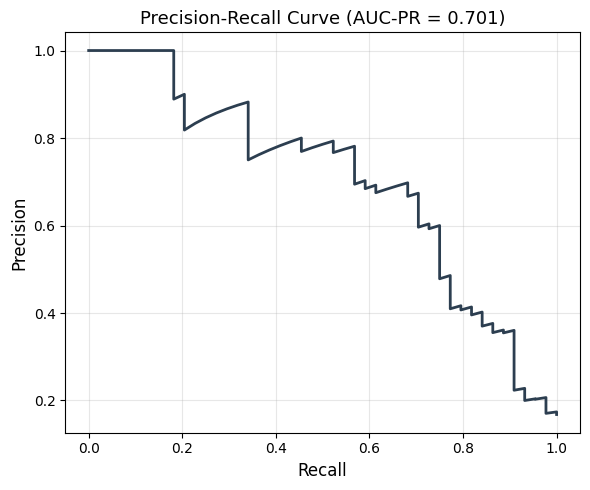

In [35]:
# ── AUC-PR computation for best model (SAGE + Focal + MC Dropout) ────────────
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

def get_probs_mc(model, test_loader, n_samples=MC_SAMPLES):
    """Same as evaluate_mc but also returns mean probability for positive class."""
    all_probs, all_labels = [], []
    for batch in test_loader:
        batch = batch.to(device)
        mean_probs, uncertainty, pred_labels = model.mc_predict(
            batch, n_samples=n_samples)
        # mean_probs is expected to be [N, 2] or [N] depending on your mc_predict impl
        all_probs  += mean_probs[:, 1].cpu().tolist() if mean_probs.dim() > 1 else mean_probs.cpu().tolist()
        all_labels += batch.y.cpu().tolist()
    return all_labels, all_probs

# Use your best trained model variable here — replace `best_sage_model`
# with whatever variable holds your SAGE+Focal+MCDropout model
labels, probs = get_probs_mc(finetuned_model, heldout_test_loader)

auc_pr = average_precision_score(labels, probs)
precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)

print(f'AUC-PR: {auc_pr:.3f}')

# ── Plot PR curve ──
plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, linewidth=2, color='#2c3e50')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve (AUC-PR = {auc_pr:.3f})', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('auc_pr_curve.png', dpi=300)
plt.show()

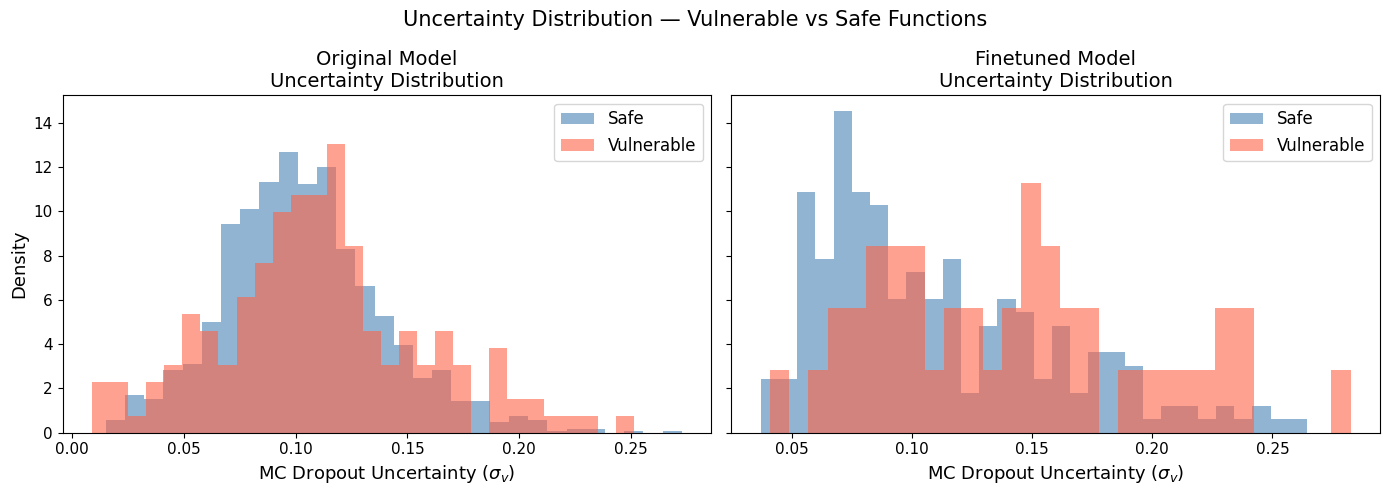

In [36]:
# ── Cell 12: Uncertainty histogram ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

unc_vuln = [u for u, l in zip(mc_unc, mc_labels) if l == 1]
unc_safe = [u for u, l in zip(mc_unc, mc_labels) if l == 0]

ft_unc_vuln = [u for u, l in zip(ft_unc, ft_labels) if l == 1]
ft_unc_safe = [u for u, l in zip(ft_unc, ft_labels) if l == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Original
axes[0].hist(unc_safe, bins=30, alpha=0.6, color='steelblue', label='Safe', density=True)
axes[0].hist(unc_vuln, bins=30, alpha=0.6, color='tomato', label='Vulnerable', density=True)
axes[0].set_title('Original Model\nUncertainty Distribution', fontsize=14)
axes[0].set_xlabel('MC Dropout Uncertainty ($\\sigma_v$)', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=12)

# Finetuned
axes[1].hist(ft_unc_safe, bins=30, alpha=0.6, color='steelblue', label='Safe', density=True)
axes[1].hist(ft_unc_vuln, bins=30, alpha=0.6, color='tomato', label='Vulnerable', density=True)
axes[1].set_title('Finetuned Model\nUncertainty Distribution', fontsize=14)
axes[1].set_xlabel('MC Dropout Uncertainty ($\\sigma_v$)', fontsize=13)
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=12)

plt.suptitle('Uncertainty Distribution — Vulnerable vs Safe Functions', fontsize=15)
plt.tight_layout()
plt.savefig('uncertainty_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

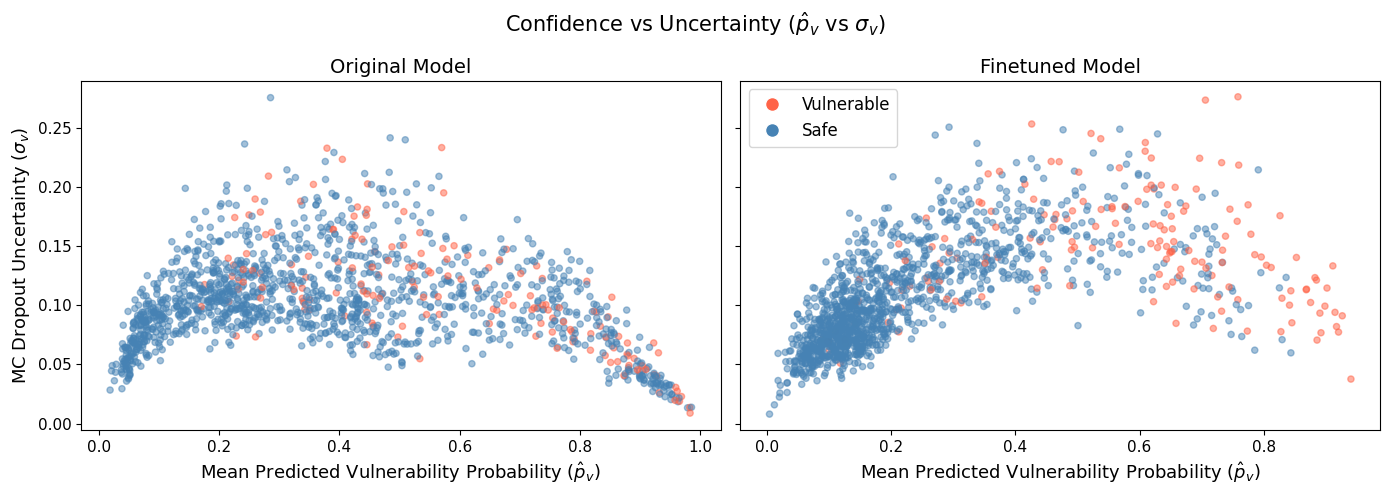

In [37]:
# ── Cell 13: Confidence scatter ─────────────────────────────────────────────────
final_model.train()
all_probs, all_labels_scatter, all_unc_scatter = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        mean_probs, uncertainty, _ = final_model.mc_predict(batch, n_samples=30)
        all_probs          += mean_probs[:, 1].cpu().tolist()
        all_labels_scatter += batch.y.cpu().tolist()
        all_unc_scatter    += uncertainty.cpu().tolist()

finetuned_model.train()
ft_probs, ft_labels_scatter, ft_unc_scatter = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        mean_probs, uncertainty, _ = finetuned_model.mc_predict(batch, n_samples=30)
        ft_probs          += mean_probs[:, 1].cpu().tolist()
        ft_labels_scatter += batch.y.cpu().tolist()
        ft_unc_scatter    += uncertainty.cpu().tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors_orig = ['tomato' if l == 1 else 'steelblue' for l in all_labels_scatter]
axes[0].scatter(all_probs, all_unc_scatter, c=colors_orig, alpha=0.5, s=20)
axes[0].set_title('Original Model', fontsize=14)
axes[0].set_xlabel('Mean Predicted Vulnerability Probability ($\\hat{p}_v$)', fontsize=13)
axes[0].set_ylabel('MC Dropout Uncertainty ($\\sigma_v$)', fontsize=13)
axes[0].tick_params(axis='both', labelsize=11)

colors_ft = ['tomato' if l == 1 else 'steelblue' for l in ft_labels_scatter]
axes[1].scatter(ft_probs, ft_unc_scatter, c=colors_ft, alpha=0.5, s=20)
axes[1].set_title('Finetuned Model', fontsize=14)
axes[1].set_xlabel('Mean Predicted Vulnerability Probability ($\\hat{p}_v$)', fontsize=13)
axes[1].tick_params(axis='both', labelsize=11)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=10, label='Vulnerable'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Safe'),
]
axes[1].legend(handles=legend_elements, fontsize=12)

plt.suptitle('Confidence vs Uncertainty ($\\hat{p}_v$ vs $\\sigma_v$)', fontsize=15)
plt.tight_layout()
plt.savefig('confidence_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Mean state-flow degree — Vulnerable: 2.30
Mean state-flow degree — Safe      : 1.65


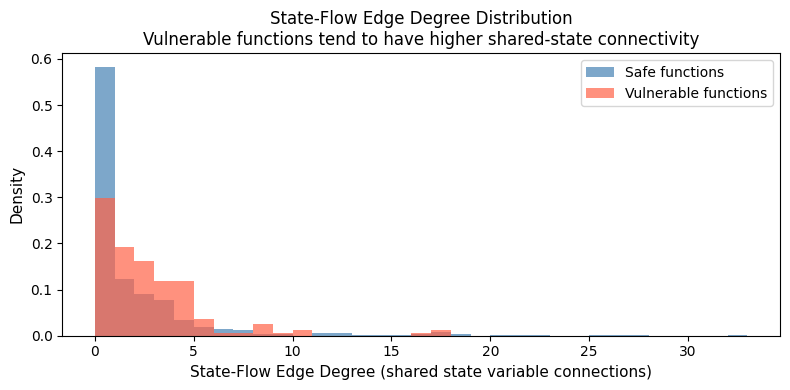

Saved: state_flow_degree.png


In [38]:
# ── Cell 14: State-flow degree distribution ────────────────────────────────────

import matplotlib.pyplot as plt

safe_state_degrees = []
vuln_state_degrees = []

for graph in dataset:
    edge_attr_np  = graph.edge_attr.numpy()
    edge_index_np = graph.edge_index.numpy()
    labels_np     = graph.y.numpy()
    n = graph.num_nodes

    state_degree = [0] * n
    for idx in range(edge_index_np.shape[1]):
        if edge_attr_np[idx] == 1:  # state-flow edge
            src = edge_index_np[0, idx]
            tgt = edge_index_np[1, idx]
            state_degree[src] += 1
            state_degree[tgt] += 1

    for deg, label in zip(state_degree, labels_np):
        if label == 1:
            vuln_state_degrees.append(deg)
        else:
            safe_state_degrees.append(deg)

print(f'Mean state-flow degree — Vulnerable: {np.mean(vuln_state_degrees):.2f}')
print(f'Mean state-flow degree — Safe      : {np.mean(safe_state_degrees):.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(safe_state_degrees,
        bins=range(0, max(safe_state_degrees or [1]) + 2),
        alpha=0.7, color='steelblue', label='Safe functions', density=True)
ax.hist(vuln_state_degrees,
        bins=range(0, max(vuln_state_degrees or [1]) + 2),
        alpha=0.7, color='tomato', label='Vulnerable functions', density=True)
ax.set_xlabel('State-Flow Edge Degree (shared state variable connections)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('State-Flow Edge Degree Distribution\n'
             'Vulnerable functions tend to have higher shared-state connectivity',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('state_flow_degree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: state_flow_degree.png')

Explaining graph with 8 functions.
Vulnerable node index: 1
Function name: FibonacciBalance.withdraw()


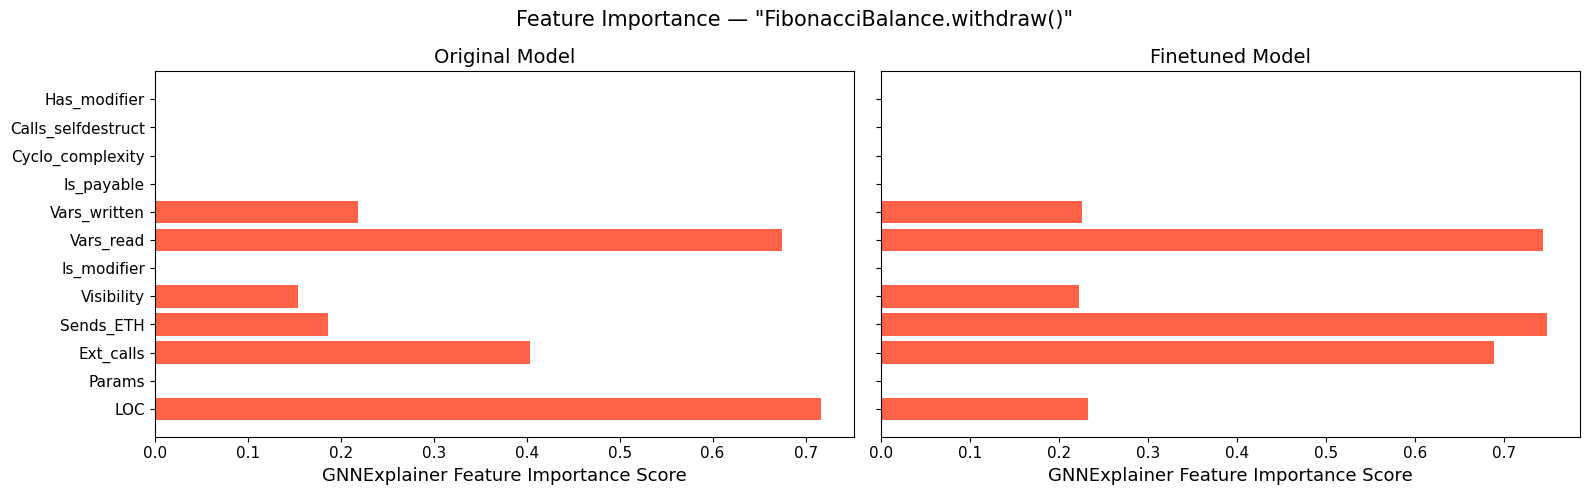


Feature importance scores (Original):
  LOC                   : 0.7161  ████████████████████████████
  Vars_read             : 0.6743  ██████████████████████████
  Ext_calls             : 0.4035  ████████████████
  Vars_written          : 0.2183  ████████
  Sends_ETH             : 0.1868  ███████
  Visibility            : 0.1540  ██████
  Params                : 0.0000  
  Is_modifier           : 0.0000  
  Is_payable            : 0.0000  
  Cyclo_complexity      : 0.0000  
  Calls_selfdestruct    : 0.0000  
  Has_modifier          : 0.0000  

Feature importance scores (Finetuned):
  Sends_ETH             : 0.7477  █████████████████████████████
  Vars_read             : 0.7436  █████████████████████████████
  Ext_calls             : 0.6883  ███████████████████████████
  LOC                   : 0.2324  █████████
  Vars_written          : 0.2263  █████████
  Visibility            : 0.2225  ████████
  Params                : 0.0000  
  Is_modifier           : 0.0000  
  Is_payable       

In [39]:
# ── Cell 15: GNNExplainer ─────────────────────────────────────────────────────
from torch_geometric.explain import Explainer, GNNExplainer
import warnings
warnings.filterwarnings('ignore')

class SAGEWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index):
        class _D: pass
        d = _D()
        d.x, d.edge_index = x, edge_index
        return self.model(d)

# ── Find target graph ──
target_graph = None
for g in dataset:
    if g.y.sum() > 0:
        target_graph = g
        break

if target_graph is None:
    print('No vulnerable graph found in test set.')
else:
    x          = target_graph.x.to(device)
    edge_index = target_graph.edge_index.to(device)
    vuln_node  = (target_graph.y == 1).nonzero(as_tuple=True)[0][0].item()

    print(f'Explaining graph with {target_graph.num_nodes} functions.')
    print(f'Vulnerable node index: {vuln_node}')
    if hasattr(target_graph, 'func_names'):
        print(f'Function name: {target_graph.func_names[vuln_node]}')

    feature_names = [
        'LOC', 'Params', 'Ext_calls', 'Sends_ETH',
        'Visibility', 'Is_modifier', 'Vars_read', 'Vars_written',
        'Is_payable', 'Cyclo_complexity', 'Calls_selfdestruct', 'Has_modifier'
    ]

    # ── Build both explainers ──
    wrapped_model    = SAGEWrapper(final_model).to(device)
    wrapped_finetuned = SAGEWrapper(finetuned_model).to(device)

    explainer = Explainer(
        model=wrapped_model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='multiclass_classification',
                          task_level='node', return_type='log_probs'),
    )
    explainer_ft = Explainer(
        model=wrapped_finetuned,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='multiclass_classification',
                          task_level='node', return_type='log_probs'),
    )

    explanation    = explainer(x=x, edge_index=edge_index, index=vuln_node)
    explanation_ft = explainer_ft(x=x, edge_index=edge_index, index=vuln_node)

    # ── Side-by-side bar chart ──
    importance_orig = explanation.node_mask[vuln_node].cpu().numpy()
    importance_ft   = explanation_ft.node_mask[vuln_node].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, imp, title in zip(axes,
                               [importance_orig, importance_ft],
                               ['Original Model', 'Finetuned Model']):
        colors = ['tomato' if i > np.median(imp) else 'steelblue' for i in imp]
        ax.barh(feature_names, imp, color=colors)
        ax.set_xlabel('GNNExplainer Feature Importance Score', fontsize=13)
        ax.set_title(title, fontsize=14)
        ax.tick_params(axis='both', labelsize=11)

    func_label = target_graph.func_names[vuln_node] if hasattr(target_graph, 'func_names') else vuln_node
    plt.suptitle(f'Feature Importance — "{func_label}"', fontsize=12)
    plt.tight_layout()
    plt.suptitle(f'Feature Importance — "{func_label}"', fontsize=15)
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('\nFeature importance scores (Original):')
    for name, score in sorted(zip(feature_names, importance_orig),
                               key=lambda x: x[1], reverse=True):
        print(f'  {name:<22}: {score:.4f}  {"█" * int(score * 40)}')

    print('\nFeature importance scores (Finetuned):')
    for name, score in sorted(zip(feature_names, importance_ft),
                               key=lambda x: x[1], reverse=True):
        print(f'  {name:<22}: {score:.4f}  {"█" * int(score * 40)}')

    print('Saved: feature_importance.png')

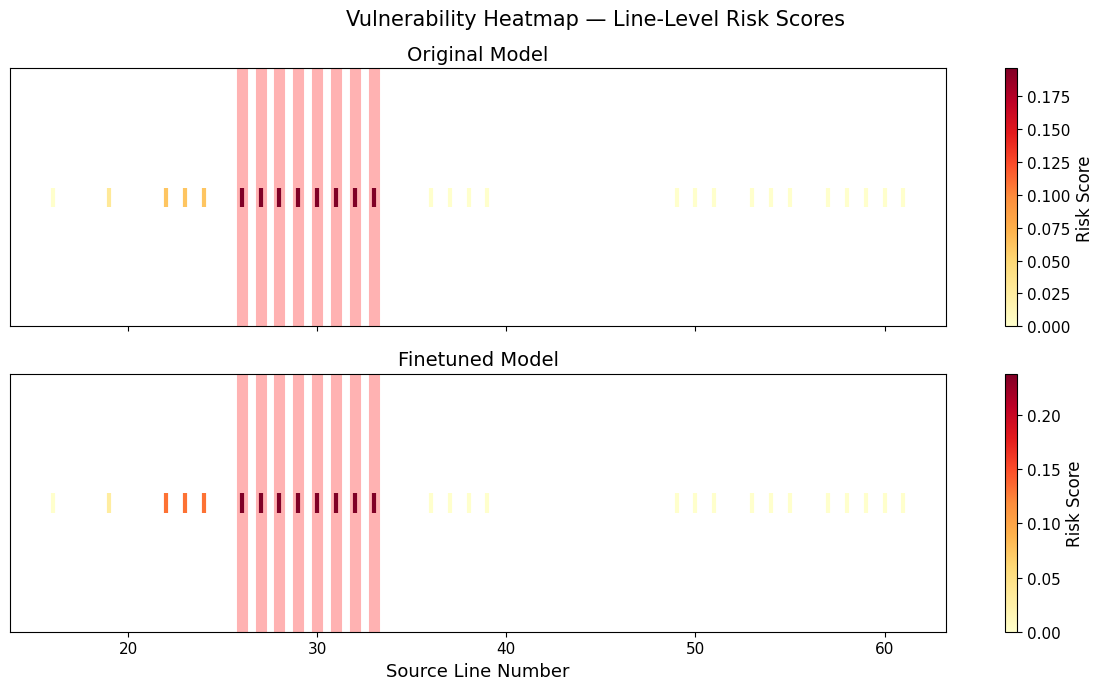

Saved: line_heatmap.png


In [40]:
# ── Cell 16: Source-line heatmap (NOVELTY #4 continued) ───────────────────────
if target_graph is not None and hasattr(target_graph, 'func_lines'):
    node_importance    = explanation.node_mask.mean(dim=1).cpu().numpy()
    node_importance_ft = explanation_ft.node_mask.mean(dim=1).cpu().numpy()

    line_scores = {}
    for i, fname in enumerate(target_graph.func_names):
        lines = target_graph.func_lines.get(fname, set())
        score = float(node_importance[i])
        for line in lines:
            line_scores[line] = max(line_scores.get(line, 0), score)

    line_scores_ft = {}
    for i, fname in enumerate(target_graph.func_names):
        lines = target_graph.func_lines.get(fname, set())
        score = float(node_importance_ft[i])
        for line in lines:
            line_scores_ft[line] = max(line_scores_ft.get(line, 0), score)

    vuln_fname = target_graph.func_names[vuln_node]
    vuln_lines = target_graph.func_lines.get(vuln_fname, set())

    if line_scores and line_scores_ft:
        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        for ax, scores_dict, title in zip(axes,
                                           [line_scores, line_scores_ft],
                                           ['Original Model', 'Finetuned Model']):
            sorted_lines = sorted(scores_dict.keys())
            scores       = [scores_dict[l] for l in sorted_lines]
            sc = ax.scatter(sorted_lines, [1]*len(sorted_lines),
                            c=scores, cmap='YlOrRd', s=200, marker='|', linewidths=3)
            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label('Risk Score', fontsize=12)
            cbar.ax.tick_params(labelsize=11)
            for vl in vuln_lines:
                ax.axvline(vl, color='red', alpha=0.3, linewidth=8, zorder=0)
            ax.set_yticks([])
            ax.set_title(title, fontsize=14)
        axes[1].set_xlabel('Source Line Number', fontsize=13)
        axes[1].tick_params(axis='x', labelsize=11)
        plt.suptitle('Vulnerability Heatmap — Line-Level Risk Scores', fontsize=15)
        plt.tight_layout()
        plt.savefig('line_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: line_heatmap.png')

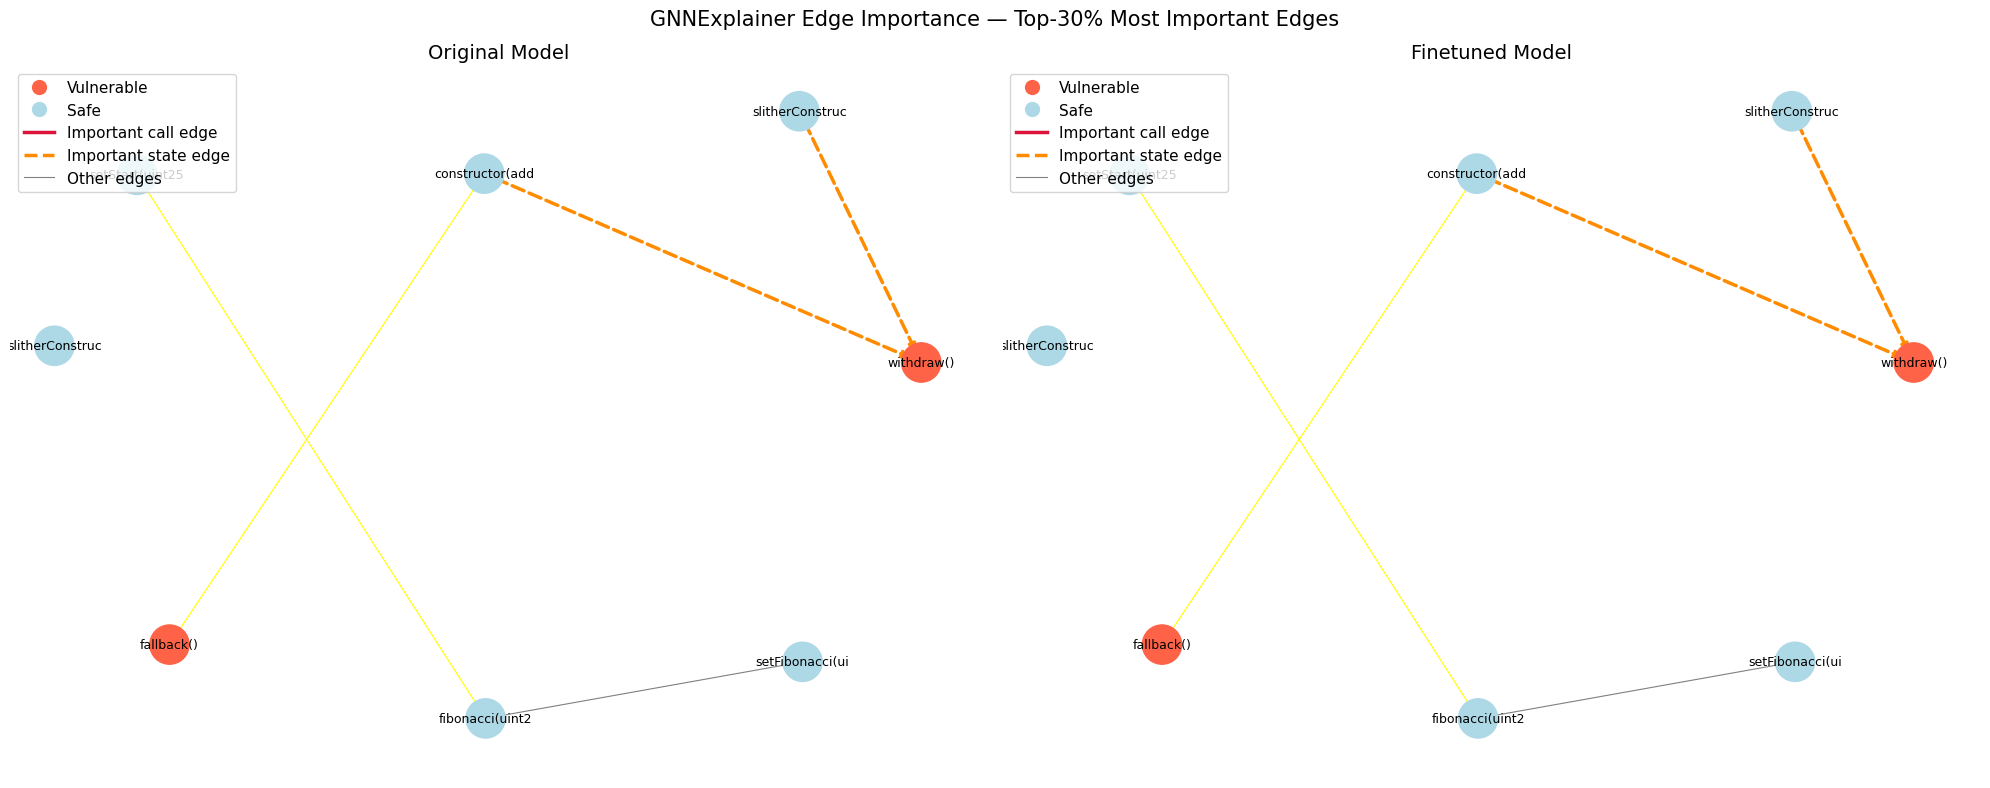

Saved: edge_importance_graph.png


In [41]:
# ── Cell 17: Edge importance ───────────────────────────────────────────────────
if target_graph is not None:
    import networkx as nx
    from matplotlib.lines import Line2D

    edge_index_np = target_graph.edge_index.numpy()
    edge_attr_np  = target_graph.edge_attr.numpy()

    node_colors = [
        'tomato' if target_graph.y[i] == 1 else 'lightblue'
        for i in range(target_graph.num_nodes)
    ]
    labels_dict = {}
    G = nx.DiGraph()
    for i in range(target_graph.num_nodes):
        name  = target_graph.func_names[i] if hasattr(target_graph, 'func_names') else str(i)
        short = name.split('.')[-1][:15]
        G.add_node(i, label=short)
        labels_dict[i] = short
    for idx in range(edge_index_np.shape[1]):
        G.add_edge(edge_index_np[0, idx], edge_index_np[1, idx])

    pos = nx.spring_layout(G, seed=42, k=2)

    def draw_edge_graph(ax, emask, title):
        threshold = np.percentile(emask, 70)
        call_imp, state_imp = [], []
        call_all, state_all = [], []
        for idx in range(edge_index_np.shape[1]):
            src, tgt  = edge_index_np[0, idx], edge_index_np[1, idx]
            etype     = edge_attr_np[idx]
            score     = emask[idx]
            if etype == 0:
                call_all.append((src, tgt))
                if score >= threshold: call_imp.append((src, tgt))
            else:
                state_all.append((src, tgt))
                if score >= threshold: state_imp.append((src, tgt))

        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=ax)
        nx.draw_networkx_labels(G, pos, labels=labels_dict, font_size=9, ax=ax)
        nx.draw_networkx_edges(G, pos,
            edgelist=[e for e in call_all  if e not in call_imp],
            edge_color='grey', width=0.8, arrows=True, ax=ax)
        nx.draw_networkx_edges(G, pos,
            edgelist=[e for e in state_all if e not in state_imp],
            edge_color='yellow', width=0.8, arrows=True, ax=ax)
        if call_imp:
            nx.draw_networkx_edges(G, pos, edgelist=call_imp,
                edge_color='crimson', width=2.5, arrows=True, ax=ax)
        if state_imp:
            nx.draw_networkx_edges(G, pos, edgelist=state_imp,
                edge_color='darkorange', width=2.5, style='dashed', arrows=True, ax=ax)

        legend_elements = [
            Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=12, label='Vulnerable'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='lightblue', markersize=12, label='Safe'),
            Line2D([0],[0], color='crimson',    linewidth=2.5, label='Important call edge'),
            Line2D([0],[0], color='darkorange', linewidth=2.5, linestyle='--', label='Important state edge'),
            Line2D([0],[0], color='grey',       linewidth=0.8, label='Other edges'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
        ax.set_title(title, fontsize=14)
        ax.axis('off')

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    draw_edge_graph(axes[0], explanation.edge_mask.cpu().numpy(),    'Original Model')
    draw_edge_graph(axes[1], explanation_ft.edge_mask.cpu().numpy(), 'Finetuned Model')

    plt.suptitle('GNNExplainer Edge Importance — Top-30% Most Important Edges', fontsize=15)
    plt.tight_layout()
    plt.savefig('edge_importance_graph.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: edge_importance_graph.png')